<a href="https://colab.research.google.com/github/nazrann233/Bitcoin-and-Gold-prediction-in-MYR/blob/main/FYP_NAZRAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# This is my new FYP
### Nazran
- The version that need to use for this part of the analysis is numpy = V1.26.4 and pmdarima = V2.0.4

# Wajib uninstall dan install package ni

*   Restart Session then Proceed to run all coding




In [1]:
!pip uninstall numpy pmdarima -y

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


In [2]:
!pip install "numpy==1.26.4" "pmdarima==2.0.4"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 35.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.36.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
o

# Pre-processing Data

## Merge The Bitcoin and Gold (XAU/MYR)

In [3]:
# Load Packages
import pandas as pd

In [4]:
# Loading Data
bitcoin = pd.read_csv('/content/drive/MyDrive/Raw Data/BTC MYR.csv')
gold = pd.read_csv('/content/drive/MyDrive/Raw Data/XAU MYR.csv')
btc_Currency= pd.read_csv('/content/drive/MyDrive/Raw Data/btcusd and currency.csv')


In [5]:

merged = pd.merge(bitcoin, gold, on='Date', how='left') ## change to 'inner' to follow XAU/MYR dates
display(merged.head())

merged['Date'] = pd.to_datetime(merged['Date'], format='%d/%m/%Y')
merged = merged.sort_values(by='Date')

merged['Bitcoin'] = pd.to_numeric(merged['BTC/MYR'].str.replace(',', ''))
merged['Gold']    = pd.to_numeric(merged['Price'].str.replace(',', ''))


##After creating the clean columns, just delete the messy ones:
merged = merged.drop(columns=['BTC/MYR', 'Price'])


# Forward-fill missing 'Gold' values
merged['Gold'] = merged['Gold'].ffill()
display(merged.head())

,Date,BTC/MYR,Price
0,1/1/2016,1862.728,"4,548.43"
1,2/1/2016,1861.4404,NaN
2,3/1/2016,1848.5644,NaN
3,4/1/2016,1873.37255,"4,662.44"
4,5/1/2016,1872.486,"4,674.01"


,Date,Bitcoin,Gold
0,2016-01-01,1862.72800,4548.43
1,2016-01-02,1861.44040,4548.43
2,2016-01-03,1848.56440,4548.43
3,2016-01-04,1873.37255,4662.44
4,2016-01-05,1872.48600,4674.01


In [6]:
display(merged[['Date', 'Bitcoin', 'Gold']].head(10))

,Date,Bitcoin,Gold
0,2016-01-01,1862.72800,4548.43
1,2016-01-02,1861.44040,4548.43
2,2016-01-03,1848.56440,4548.43
3,2016-01-04,1873.37255,4662.44
4,2016-01-05,1872.48600,4674.01
5,2016-01-06,1882.38060,4799.37
6,2016-01-07,2017.19800,4867.63
7,2016-01-08,1979.39945,4828.91
8,2016-01-09,1959.29515,4828.91
9,2016-01-10,1950.11710,4828.91


## Raw Data Bitcoin and Gold(XAU/MYR) plot


In [7]:
import numpy as np

In [8]:
import matplotlib.pyplot as plt

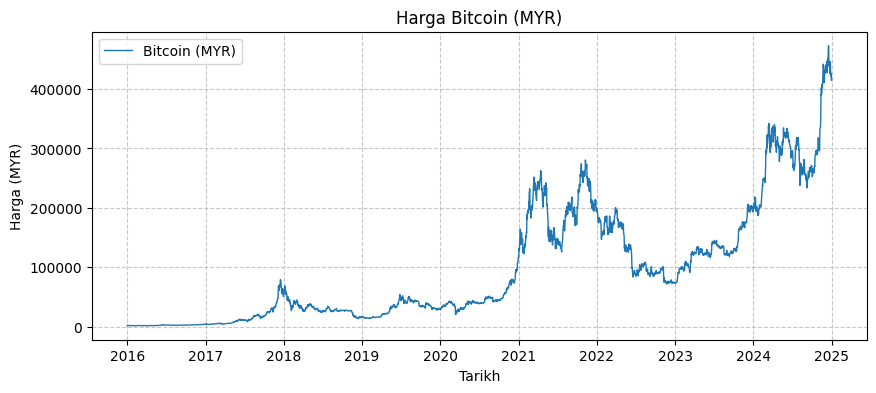

In [9]:
plt.figure(figsize=(10,4))
plt.plot(merged['Date'], merged['Bitcoin'], label='Bitcoin (MYR)', linewidth=1)
plt.title('Harga Bitcoin (MYR)')
plt.xlabel('Tarikh')
plt.ylabel('Harga (MYR)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

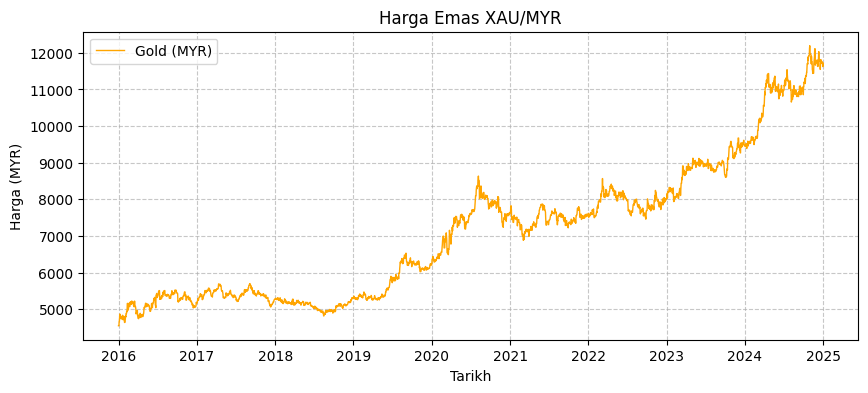

In [10]:
plt.figure(figsize=(10,4))
plt.plot(merged['Date'], merged['Gold'], label='Gold (MYR)', color='orange', linewidth=1)
plt.title('Harga Emas XAU/MYR')
plt.xlabel('Tarikh')
plt.ylabel('Harga (MYR)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Raw Bitcoin and Gold ADF

In [11]:
from statsmodels.tsa.stattools import adfuller

In [12]:
# ADF ON RAW DATA
# ========================
from statsmodels.tsa.stattools import adfuller

def adf_print(series, name):
    res = adfuller(series.dropna())
    print(f"\n--- ADF Test: {name} ---")
    print(f"ADF Statistic: {res[0]:.6f}")
    print(f"p-value     : {res[1]:.6f}")
    for k, v in res[4].items():
        print(f"Critical Value ({k}): {v:.4f}")
    print("→ Stationary ✅" if res[1] < 0.05 else "→ Non-stationary ❌")

adf_print(merged['Bitcoin'], 'Raw Bitcoin')
adf_print(merged['Gold'],    'Raw Gold')


--- ADF Test: Raw Bitcoin ---
ADF Statistic: -0.101811
p-value     : 0.949258
Critical Value (1%): -3.4324
Critical Value (5%): -2.8624
Critical Value (10%): -2.5672
→ Non-stationary ❌

--- ADF Test: Raw Gold ---
ADF Statistic: 0.725288
p-value     : 0.990329
Critical Value (1%): -3.4323
Critical Value (5%): -2.8624
Critical Value (10%): -2.5672
→ Non-stationary ❌


## Log Return

In [13]:
# Calculate log returns (natural log difference between consecutive prices)
merged['Bitcoin_logret'] = np.log(merged['Bitcoin'] / merged['Bitcoin'].shift(1))
merged['Gold_logret']    = np.log(merged['Gold'] / merged['Gold'].shift(1))

# Drop any missing values caused by the shift
merged = merged.dropna(subset=['Bitcoin_logret', 'Gold_logret'])

# Display first few rows to check
display(merged[['Date', 'Bitcoin_logret', 'Gold_logret']].head(10))

,Date,Bitcoin_logret,Gold_logret
1,2016-01-02,-0.000691,0.000000
2,2016-01-03,-0.006941,0.000000
3,2016-01-04,0.013331,0.024757
4,2016-01-05,-0.000473,0.002478
5,2016-01-06,0.005270,0.026467
6,2016-01-07,0.069172,0.014123
7,2016-01-08,-0.018916,-0.007986
8,2016-01-09,-0.010209,0.000000
9,2016-01-10,-0.004695,0.000000
10,2016-01-11,0.009742,-0.007723


In [14]:
# ADF ON LOG RETURNS
# ========================
from statsmodels.tsa.stattools import adfuller

def adf_print(series, name):
    res = adfuller(series.dropna())
    print(f"\n--- ADF Test: {name} ---")
    print(f"ADF Statistic: {res[0]:.6f}")
    print(f"p-value     : {res[1]:.6f}")
    for k, v in res[4].items():
        print(f"Critical Value ({k}): {v:.4f}")
    print("→ Stationary ✅" if res[1] < 0.05 else "→ Non-stationary ❌")

adf_print(merged['Bitcoin_logret'], 'Bitcoin Log Return')
adf_print(merged['Gold_logret'],    'Gold Log Return')


--- ADF Test: Bitcoin Log Return ---
ADF Statistic: -39.946681
p-value     : 0.000000
Critical Value (1%): -3.4323
Critical Value (5%): -2.8624
Critical Value (10%): -2.5672
→ Stationary ✅

--- ADF Test: Gold Log Return ---
ADF Statistic: -43.300169
p-value     : 0.000000
Critical Value (1%): -3.4323
Critical Value (5%): -2.8624
Critical Value (10%): -2.5672
→ Stationary ✅


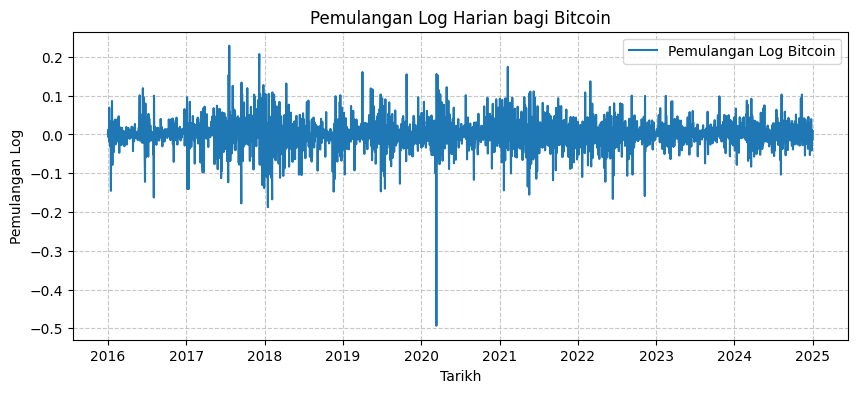

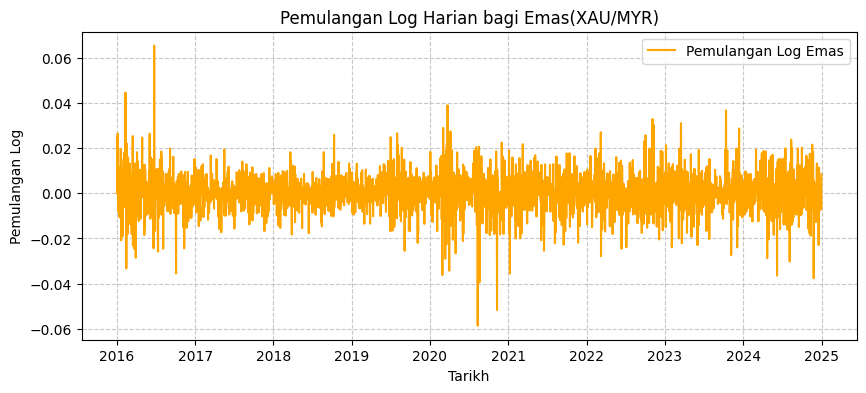

In [25]:
#Plot the log returns ---
plt.figure(figsize=(10,4))
plt.plot(merged['Date'], merged['Bitcoin_logret'], label='Pemulangan Log Bitcoin')
plt.title('Pemulangan Log Harian bagi Bitcoin')
plt.xlabel('Tarikh')
plt.ylabel('Pemulangan Log')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(merged['Date'], merged['Gold_logret'], label='Pemulangan Log Emas', color='orange')
plt.title('Pemulangan Log Harian bagi Emas(XAU/MYR)')
plt.xlabel('Tarikh')
plt.ylabel('Pemulangan Log')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

##  ACF and PACF of Log Returns( measures "How much did the price change?") (Direction and amount)


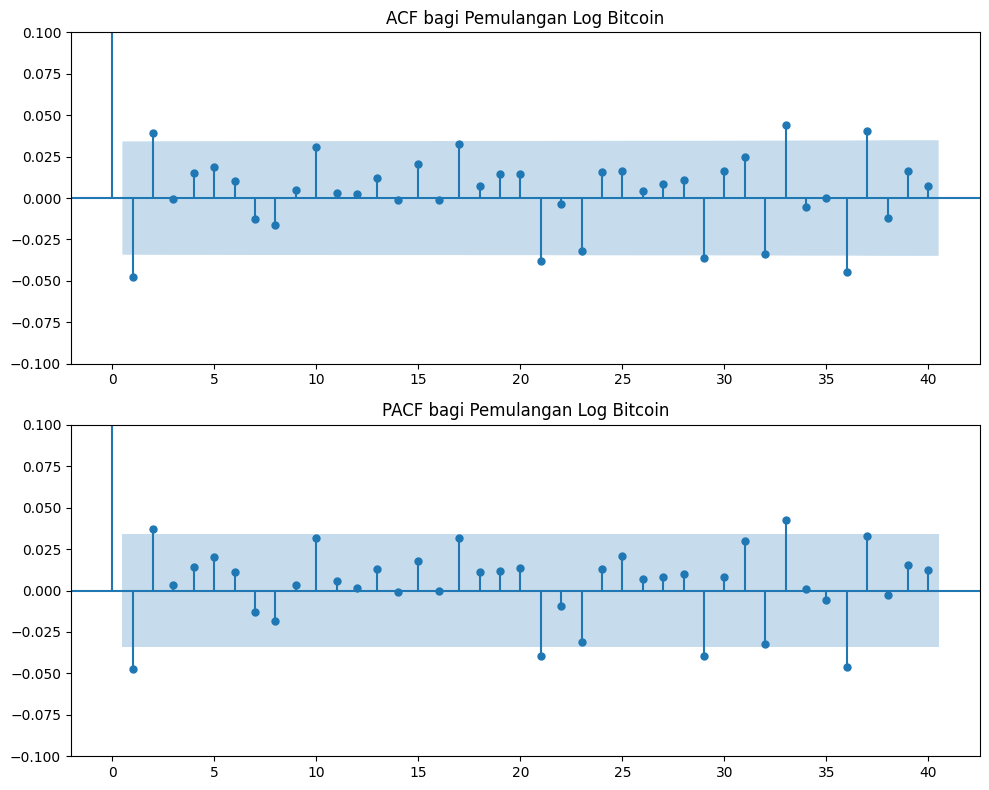

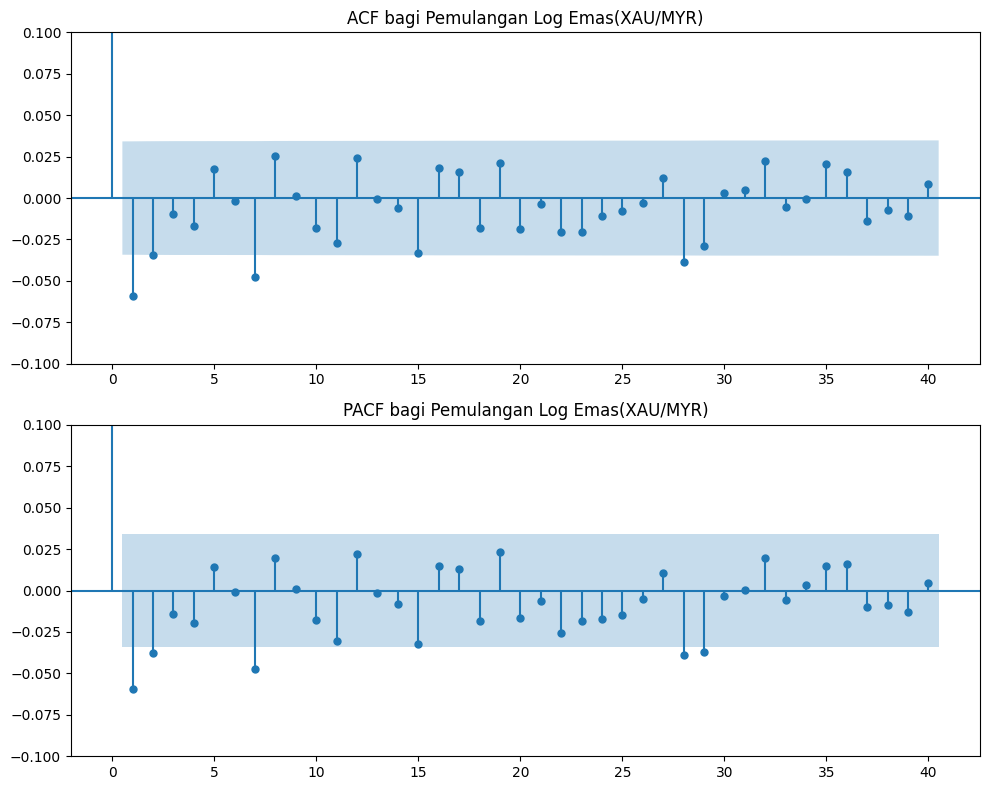

In [26]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for Bitcoin Log Returns
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(merged['Bitcoin_logret'].dropna(), ax=axes[0], lags=40)
plot_pacf(merged['Bitcoin_logret'].dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF bagi Pemulangan Log Bitcoin')
axes[1].set_title('PACF bagi Pemulangan Log Bitcoin')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Plot ACF and PACF for Gold Log Returns
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(merged['Gold_logret'].dropna(), ax=axes[0], lags=40)
plot_pacf(merged['Gold_logret'].dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF bagi Pemulangan Log Emas(XAU/MYR)')
axes[1].set_title('PACF bagi Pemulangan Log Emas(XAU/MYR)')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

## ACF and PACF Squared Log Returns (This measures "How volatile was the market?") (Magnitude/Risk only, ignoring direction).


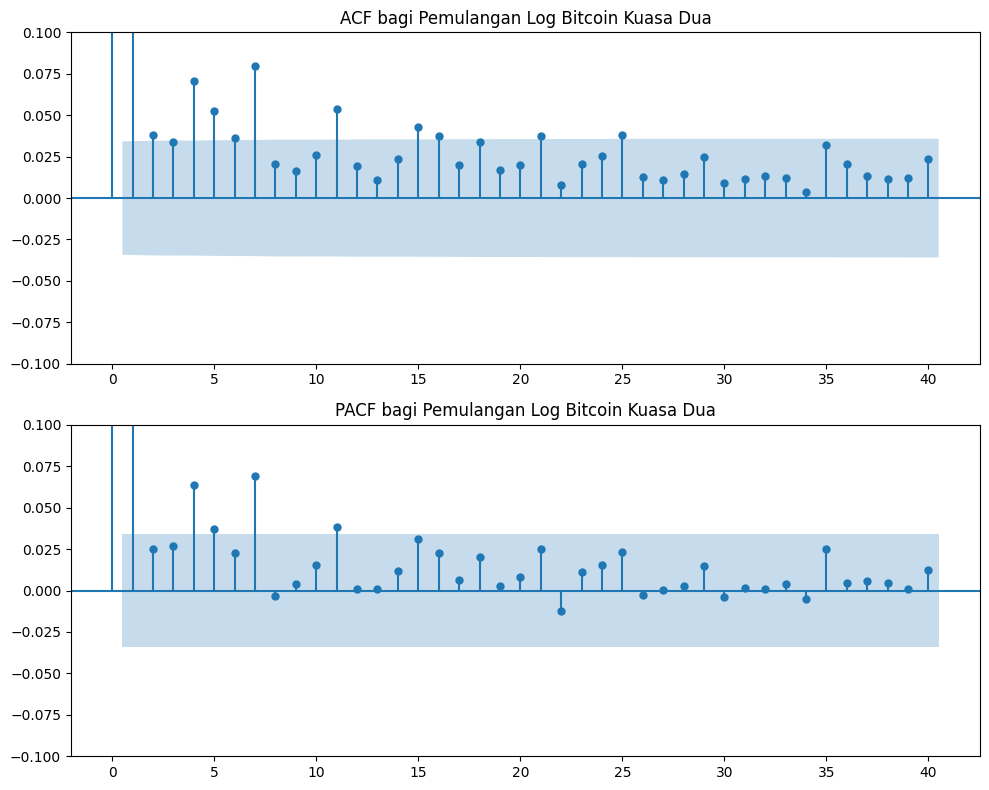

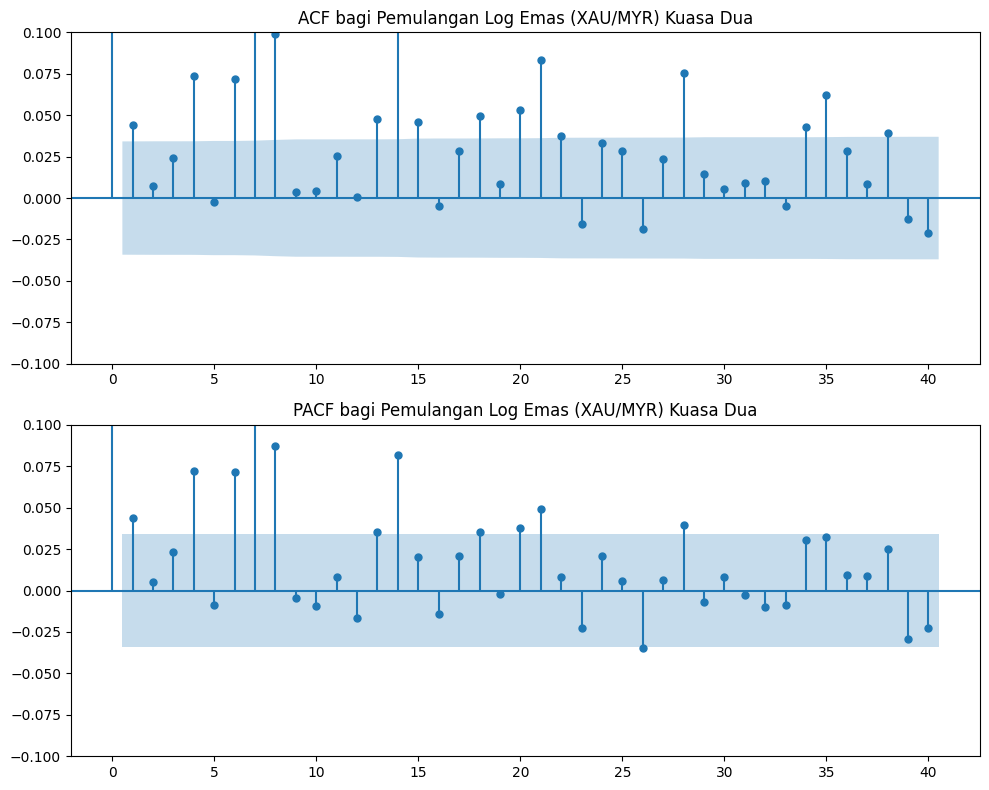

In [27]:
# Calculate squared log returns
merged['Bitcoin_logret_sq'] = merged['Bitcoin_logret']**2
merged['Gold_logret_sq'] = merged['Gold_logret']**2

# Plot ACF and PACF for squared Bitcoin Log Returns
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(merged['Bitcoin_logret_sq'].dropna(), ax=axes[0], lags=40)
plot_pacf(merged['Bitcoin_logret_sq'].dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF bagi Pemulangan Log Bitcoin Kuasa Dua')
axes[1].set_title('PACF bagi Pemulangan Log Bitcoin Kuasa Dua')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Plot ACF and PACF for squared Gold Log Returns
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(merged['Gold_logret_sq'].dropna(), ax=axes[0], lags=40)
plot_pacf(merged['Gold_logret_sq'].dropna(), ax=axes[1], lags=40)
axes[0].set_title('ACF bagi Pemulangan Log Emas (XAU/MYR) Kuasa Dua')
axes[1].set_title('PACF bagi Pemulangan Log Emas (XAU/MYR) Kuasa Dua')
axes[0].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
axes[1].set_ylim([-0.1, 0.1]) # Adjust y-axis limits to exclude lag 0 spike
plt.tight_layout()
plt.show()

# Does the USD/MYR Exchange Rate Affect Bitcoin Prices?

In [18]:
# @title
btc_Currency.head()
btc_Currency.columns

Index(['Date', 'BTC/USD', 'USD/MYR', 'Unnamed: 3'], dtype='object')

In [28]:
import pandas as pd
import numpy as np  # <--- Added numpy for log calculations

# Copy original
df = btc_Currency.copy()

# --- Clean column names robustly ---
df = df.rename(columns={
    df.columns[0]: 'Date',
    df.columns[1]: 'BTC_USD',
    df.columns[2]: 'USD_MYR'
})

# --- Date & numeric cleaning ---
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['BTC_USD'] = pd.to_numeric(df['BTC_USD'], errors='coerce')
df['USD_MYR'] = pd.to_numeric(df['USD_MYR'], errors='coerce')

# Keep only rows with valid numbers
df = df.dropna(subset=['Date', 'BTC_USD', 'USD_MYR'])

# Sort by date
df = df.sort_values('Date')

# --- 1. Log Returns Calculation (The Main Change) ---
# Formula: ln(Price_t / Price_t-1)
df['BTC_Log_Return'] = np.log(df['BTC_USD'] / df['BTC_USD'].shift(1))
df['FX_Log_Return']  = np.log(df['USD_MYR'] / df['USD_MYR'].shift(1))

# Drop NaN values created by shift(1)
returns = df[['BTC_Log_Return', 'FX_Log_Return']].dropna()

# --- 2. Volatility (Standard Deviation of Log Returns) ---
btc_std = returns['BTC_Log_Return'].std()
fx_std  = returns['FX_Log_Return'].std()

print("=== VOLATILITY (Std Dev of Daily Log Returns) ===")
print(f"Bitcoin Log Volatility : {btc_std:.4f}")
print(f"USD/MYR Log Volatility : {fx_std:.4f}")

# Avoid division by zero error just in case
if fx_std != 0:
    print(f"Bitcoin is {(btc_std / fx_std):.1f}x more volatile.\n")
else:
    print("USD/MYR Volatility is zero (cannot compare ratio).\n")

# --- 3. Correlation ---
corr = returns['BTC_Log_Return'].corr(returns['FX_Log_Return'])

print("=== CORRELATION RESULT ===")
print(f"BTC vs FX Log Correlation : {corr:.4f}\n")

# --- 4. Interpretation ---
print("=== INTERPRETATION ===")
if btc_std > fx_std * 10:
    print("Bitcoin volatility is FAR higher → currency effect is negligible.")
else:
    print("Bitcoin volatility is higher but not extremely → some FX influence exists.")

if abs(corr) < 0.2:
    print("Correlation is very low → BTC movements are basically independent of FX.")
elif abs(corr) < 0.5:
    print("Moderate correlation → FX has some influence.")
else:
    print("High correlation → FX strongly affects BTC.")

=== VOLATILITY (Std Dev of Daily Log Returns) ===
Bitcoin Log Volatility : 0.0271
USD/MYR Log Volatility : 0.0049
Bitcoin is 5.5x more volatile.

=== CORRELATION RESULT ===
BTC vs FX Log Correlation : 0.0562

=== INTERPRETATION ===
Bitcoin volatility is higher but not extremely → some FX influence exists.
Correlation is very low → BTC movements are basically independent of FX.


# Descriptive Statistic

In [29]:
# Calculate and display descriptive statistics for log returns
print("Descriptive statistics for Bitcoin Log Returns:")
display(merged['Bitcoin_logret'].describe())

print("\nDescriptive statistics for Gold Log Returns:")
display(merged['Gold_logret'].describe())

print("\nSkewness for Bitcoin Log Returns:", merged['Bitcoin_logret'].skew())
print("Kurtosis for Bitcoin Log Returns:", merged['Bitcoin_logret'].kurtosis())

print("\nSkewness for Gold Log Returns:", merged['Gold_logret'].skew())
print("Kurtosis for Gold Log Returns:", merged['Gold_logret'].kurtosis())

Descriptive statistics for Bitcoin Log Returns:


,Bitcoin_logret
count,3287.000000
mean,0.001647
std,0.037115
min,-0.493155
25%,-0.012858
50%,0.001425
75%,0.017328
max,0.228652



Descriptive statistics for Gold Log Returns:


,Gold_logret
count,3287.000000
mean,0.000288
std,0.007686
min,-0.058673
25%,-0.002181
50%,0.000000
75%,0.003132
max,0.065374



Skewness for Bitcoin Log Returns: -0.7764972643845415
Kurtosis for Bitcoin Log Returns: 12.947395640975998

Skewness for Gold Log Returns: -0.14235743872692705
Kurtosis for Gold Log Returns: 6.47255826693234


# Splitting for stationary data

In [30]:
# --- 1. Split 70:30 ---
print("--- 70:30 Split ---")
train_size = int(len(merged) * 0.7)
train_data = merged[['Date', 'Bitcoin_logret', 'Gold_logret']].iloc[0:train_size]
test_data = merged[['Date', 'Bitcoin_logret', 'Gold_logret']].iloc[train_size:len(merged)]

print("Training data size (70%):", len(train_data))
print("Testing data size (30%):", len(test_data))
print() # Adds a blank line

# --- 2. Split 75:25 ---
print("--- 75:25 Split ---")
train75_size = int(len(merged) * 0.75)
train75_data = merged[['Date', 'Bitcoin_logret', 'Gold_logret']].iloc[0:train75_size]
test75_data = merged[['Date', 'Bitcoin_logret', 'Gold_logret']].iloc[train75_size:len(merged)]

print("Training data size (75%):", len(train75_data))
print("Testing data size (25%):", len(test75_data))
print() # Adds a blank line

# --- 3. Split 80:20 ---
print("--- 80:20 Split ---")
train_size_80 = int(len(merged) * 0.80)
train_data_80 = merged[['Date', 'Bitcoin_logret', 'Gold_logret']].iloc[0:train_size_80]
test_data_80 = merged[['Date', 'Bitcoin_logret', 'Gold_logret']].iloc[train_size_80:len(merged)]

print("Training data size (80%):", len(train_data_80))
print("Testing data size (20%):", len(test_data_80))

--- 70:30 Split ---
Training data size (70%): 2300
Testing data size (30%): 987

--- 75:25 Split ---
Training data size (75%): 2465
Testing data size (25%): 822

--- 80:20 Split ---
Training data size (80%): 2629
Testing data size (20%): 658


# ARIMA(scalled*100)

*   All 3 splitting arima




In [22]:
from pmdarima import auto_arima

import pmdarima as pm

import warnings
warnings.filterwarnings("ignore")

In [38]:
import pmdarima as pm

# --- 1. Define the Function ---
def fit_and_print_arima(train_df, split_label):
    """
    Fits Auto ARIMA for Bitcoin and Gold, prints summaries,
    and returns the model objects.
    """
    print(f"\n{'='*20} Processing {split_label} Split {'='*20}")

    # --- Bitcoin Model ---
    print(f"\n--- Fitting Bitcoin ARIMA ({split_label}) ---")
    model_bitcoin = pm.auto_arima(train_df['Bitcoin_logret']*100,
                                  start_p=1, start_q=1,
                                  max_p=5, max_q=5,
                                  m=1,              # frequency of series
                                  d=None,           # let model determine 'd'
                                  seasonal=False,   # No seasonality
                                  test='adf',       # use ADF test to find 'd'
                                  trace=True,
                                  error_action='ignore',
                                  suppress_warnings=True,
                                  stepwise=True)

    print(f"Bitcoin Auto ARIMA Model Summary ({split_label}):")
    print(model_bitcoin.summary())

    # --- Gold Model ---
    print(f"\n--- Fitting Gold ARIMA ({split_label}) ---")
    model_gold = pm.auto_arima(train_df['Gold_logret']*100,
                               start_p=1, start_q=1,
                               max_p=5, max_q=5,
                               m=1,
                               d=None,
                               seasonal=False,
                               test='adf',
                               trace=True,
                               error_action='ignore',
                               suppress_warnings=True,
                               stepwise=True)

    print(f"\nGold Auto ARIMA Model Summary ({split_label}):")
    print(model_gold.summary())

    return model_bitcoin, model_gold

# --- 2. Execute Function for All Splits ---

# Run for 70:30 Split (uses 'train_data' from previous steps)
model_btc_70, model_gold_70 = fit_and_print_arima(train_data, "70:30")

# Run for 75:25 Split (uses 'train75_data' from previous steps)
model_btc_75, model_gold_75 = fit_and_print_arima(train75_data, "75:25")

# Run for 80:20 Split (uses 'train_data_80' from previous steps)
model_btc_80, model_gold_80 = fit_and_print_arima(train_data_80, "80:20")


==================== Processing 70:30 Split ====================

--- Fitting Bitcoin ARIMA (70:30) ---
Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=12951.207, Time=0.45 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=12954.758, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=12951.346, Time=0.08 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=12951.693, Time=0.13 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=12949.358, Time=1.00 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=12950.841, Time=0.23 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=12954.804, Time=0.75 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=12950.056, Time=3.86 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=12949.717, Time=0.99 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=12952.811, Time=0.20 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=12951.718, Time=1.86 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=12949.117, Time=0.72 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=12947.

In [42]:
import pmdarima as pm

def display_full_summaries(train_series, model_orders, intercept_list, label):
    print(f"\n{'#'*30}")
    print(f" FULL SUMMARIES FOR {label} ")
    print(f"{'#'*30}")

    for i, (order, has_intercept) in enumerate(zip(model_orders, intercept_list), 1):
        print(f"\n>>> Model {i}: ARIMA{order} | Intercept: {has_intercept}")

        # Fit model mengikut spesifikasi jadual
        model = pm.ARIMA(order=order, with_intercept=has_intercept).fit(train_series)

        # Paparkan rumusan penuh (termasuk AIC, BIC, HQIC, Log Likelihood)
        print(model.summary())
        print("-" * 80)

# --- 1. Bitcoin 70:30 ---
btc_orders_70 = [(2,0,0), (1,0,0), (1,0,1), (0,0,1), (2,0,1)]
btc_int_70 = [True, True, True, True, True]
display_full_summaries(train_data['Bitcoin_logret']*100, btc_orders_70, btc_int_70, "BITCOIN 70:30")

# --- 2. Bitcoin 75:25 ---
btc_orders_75 = [(0,0,2), (1,0,1), (2,0,1), (2,0,1), (3,0,1)]
btc_int_75 = [True, True, True, False, False]
display_full_summaries(train75_data['Bitcoin_logret']*100, btc_orders_75, btc_int_75, "BITCOIN 75:25")

# --- 3. Bitcoin 80:20 ---
btc_orders_80 = [(0,0,2), (1,0,1), (2,0,1), (1,0,0), (3,0,1)]
btc_int_80 = [True, True, True, True, True]
display_full_summaries(train_data_80['Bitcoin_logret']*100, btc_orders_80, btc_int_80, "BITCOIN 80:20")


##############################
 FULL SUMMARIES FOR BITCOIN 70:30 
##############################

>>> Model 1: ARIMA(2, 0, 0) | Intercept: True
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2300
Model:               SARIMAX(2, 0, 0)   Log Likelihood               -6469.561
Date:                Sat, 17 Jan 2026   AIC                          12947.122
Time:                        08:02:23   BIC                          12970.085
Sample:                             0   HQIC                         12955.494
                               - 2300                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2018      0.086      2.336      0.020       0.03

In [43]:
import pmdarima as pm

def display_gold_summaries(train_series, model_orders, intercept_list, label):
    print(f"\n{'#'*40}")
    print(f" RUMUSAN PENUH MODEL EMAS ({label}) ")
    print(f"{'#'*40}")

    for i, (order, has_intercept) in enumerate(zip(model_orders, intercept_list), 1):
        # Menentukan label intercept untuk paparan
        int_text = "Ya" if has_intercept else "Tidak"
        print(f"\n>>> Model {i}: ARIMA{order} | Pemalar: {int_text}")

        # Fit model mengikut spesifikasi jadual (Data siri masa didarab 100)
        model = pm.ARIMA(order=order, with_intercept=has_intercept).fit(train_series)

        # Paparkan rumusan (Summary mengandungi BIC, AIC, dan statistik ujian)
        print(model.summary())
        print("-" * 85)

# --- 1. Emas (70:30) ---
# Berdasarkan jadual: (3,0,3)Ya, (2,0,2)Ya, (3,0,4)Ya, (3,0,3)Tidak, (2,0,2)Tidak
gold_orders_70 = [(3,0,3), (2,0,2), (3,0,4), (3,0,3), (2,0,2)]
gold_int_70 = [True, True, True, False, False]
# Ganti 'train_data' dengan nama pembolehubah siri masa emas anda
display_gold_summaries(train_data['Gold_logret']*100, gold_orders_70, gold_int_70, "70:30")

# --- 2. Emas (75:25) ---
# Berdasarkan jadual: (1,0,1)Ya, (1,0,1)Tidak, (0,0,2)Ya, (2,0,0)Ya, (2,0,1)Ya
gold_orders_75 = [(1,0,1), (1,0,1), (0,0,2), (2,0,0), (2,0,1)]
gold_int_75 = [True, False, True, True, True]
display_gold_summaries(train75_data['Gold_logret']*100, gold_orders_75, gold_int_75, "75:25")

# --- 3. Emas (80:20) ---
# Berdasarkan jadual: (0,0,2)Ya, (1,0,1)Ya, (2,0,1)Ya, (1,0,0)Ya, (3,0,1)Ya
gold_orders_80 = [(0,0,2), (1,0,1), (2,0,1), (1,0,0), (3,0,1)]
gold_int_80 = [True, True, True, True, True]
display_gold_summaries(train_data_80['Gold_logret']*100, gold_orders_80, gold_int_80, "80:20")


########################################
 RUMUSAN PENUH MODEL EMAS (70:30) 
########################################

>>> Model 1: ARIMA(3, 0, 3) | Pemalar: Ya
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2300
Model:               SARIMAX(3, 0, 3)   Log Likelihood               -2615.145
Date:                Sat, 17 Jan 2026   AIC                           5246.290
Time:                        08:09:27   BIC                           5292.215
Sample:                             0   HQIC                          5263.034
                               - 2300                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0085      0.006      1.511      

# Plot Reja

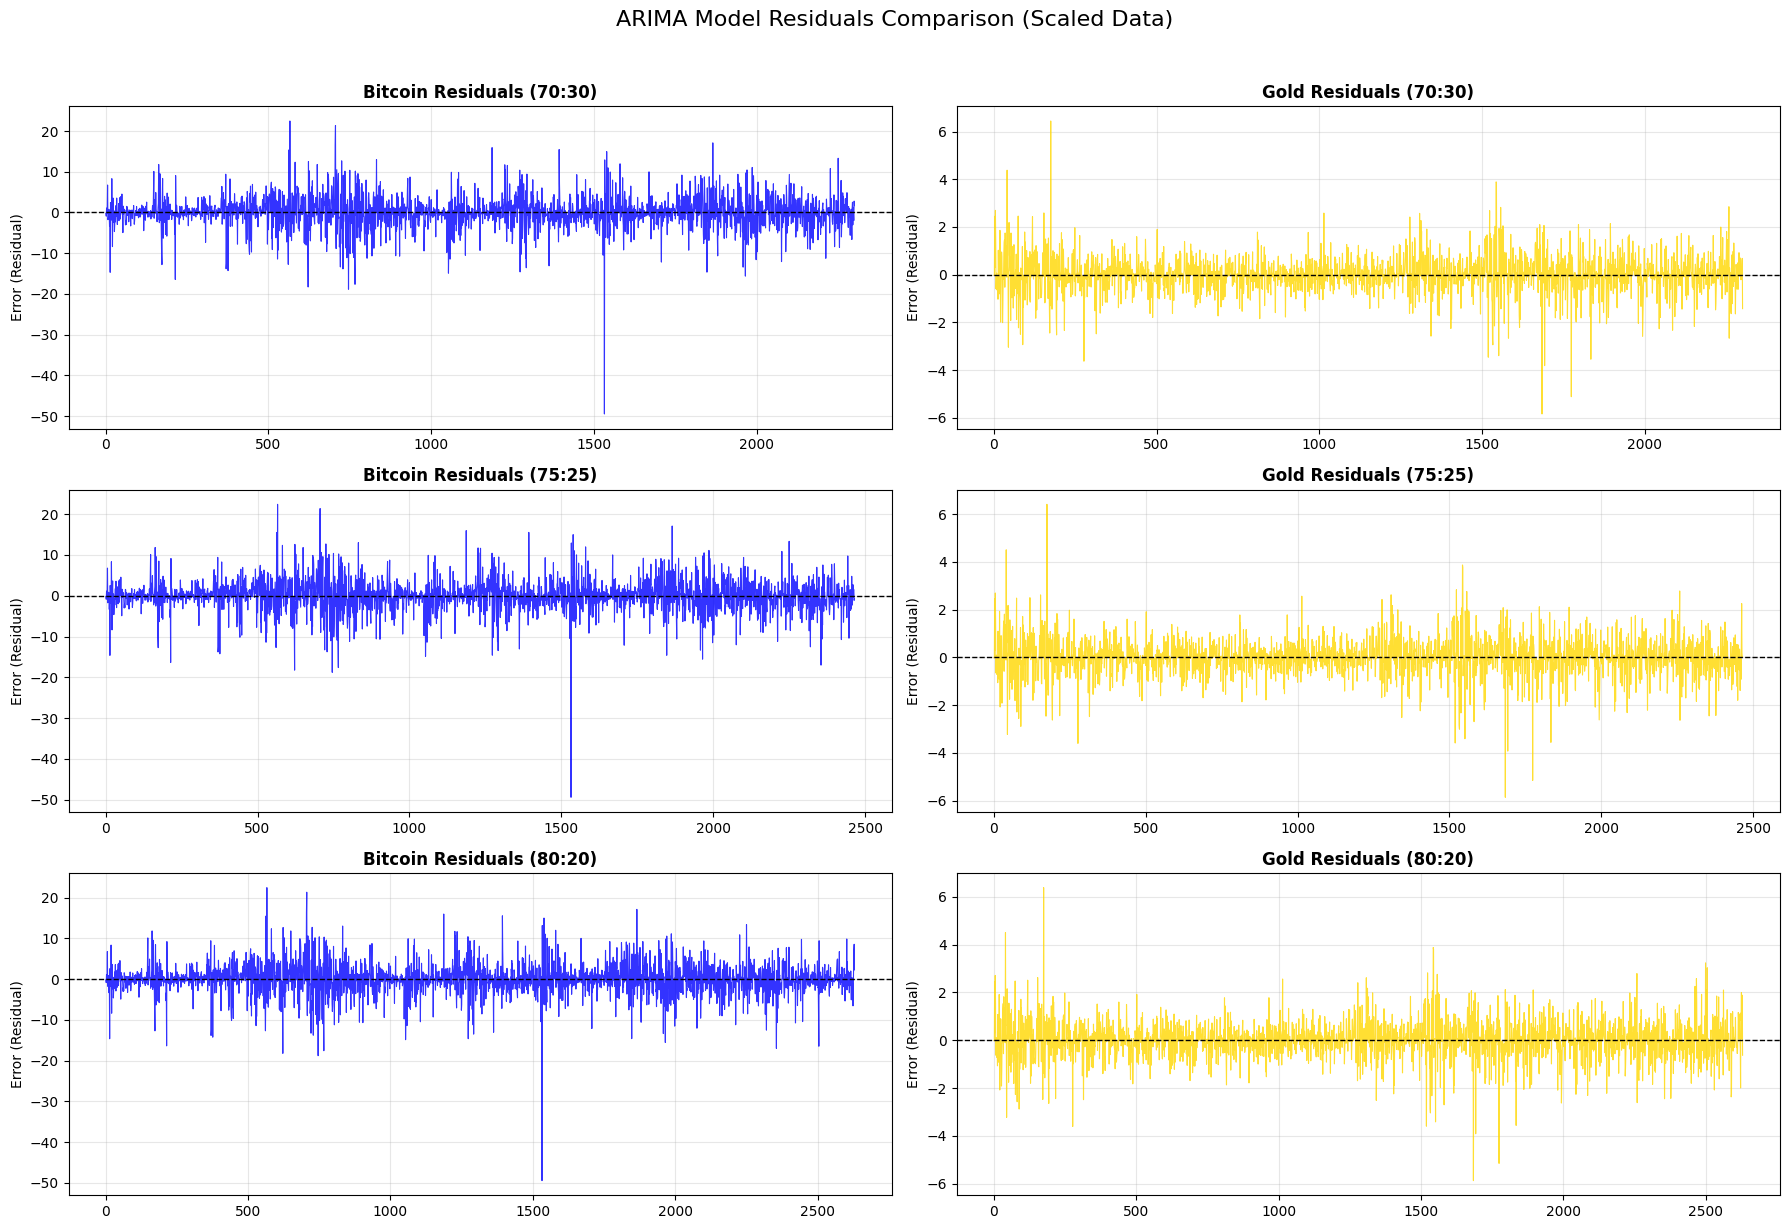

In [34]:
import matplotlib.pyplot as plt

def plot_all_residuals_comparison(btc70, gold70, btc75, gold75, btc80, gold80):
    """
    Plots the residuals of all 3 splits for Bitcoin and Gold in a single 3x2 grid.

    Parameters:
    The fitted ARIMA model objects from the previous step.
    """

    # Create a figure with 3 rows (Splits) and 2 columns (Assets)
    fig, axes = plt.subplots(3, 2, figsize=(18, 12), sharex=False)

    # Data structure to make plotting easy
    # Format: (Model Object, Title, Axis Location)
    plot_config = [
        # Row 1: 70:30 Split
        (btc70, "Bitcoin Residuals (70:30)", axes[0, 0], 'blue'),
        (gold70, "Gold Residuals (70:30)", axes[0, 1], 'gold'),

        # Row 2: 75:25 Split
        (btc75, "Bitcoin Residuals (75:25)", axes[1, 0], 'blue'),
        (gold75, "Gold Residuals (75:25)", axes[1, 1], 'gold'),

        # Row 3: 80:20 Split
        (btc80, "Bitcoin Residuals (80:20)", axes[2, 0], 'blue'),
        (gold80, "Gold Residuals (80:20)", axes[2, 1], 'gold')
    ]

    # Loop through the config and plot
    for model, title, ax, color in plot_config:
        residuals = model.resid() # Extract residuals

        ax.plot(residuals, color=color, linewidth=0.8, alpha=0.8)
        ax.axhline(0, color='black', linestyle='--', linewidth=1) # Zero line
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_ylabel("Error (Residual)", fontsize=10)
        ax.grid(True, alpha=0.3)

    # Adjust layout
    plt.suptitle("ARIMA Model Residuals Comparison (Scaled Data)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# --- Execute the Function ---
# Passing the variables created in the previous step
plot_all_residuals_comparison(
    model_btc_70, model_gold_70,
    model_btc_75, model_gold_75,
    model_btc_80, model_gold_80
)

# Diagnostic Check


==================== DIAGNOSTICS: Bitcoin (70:30) ====================


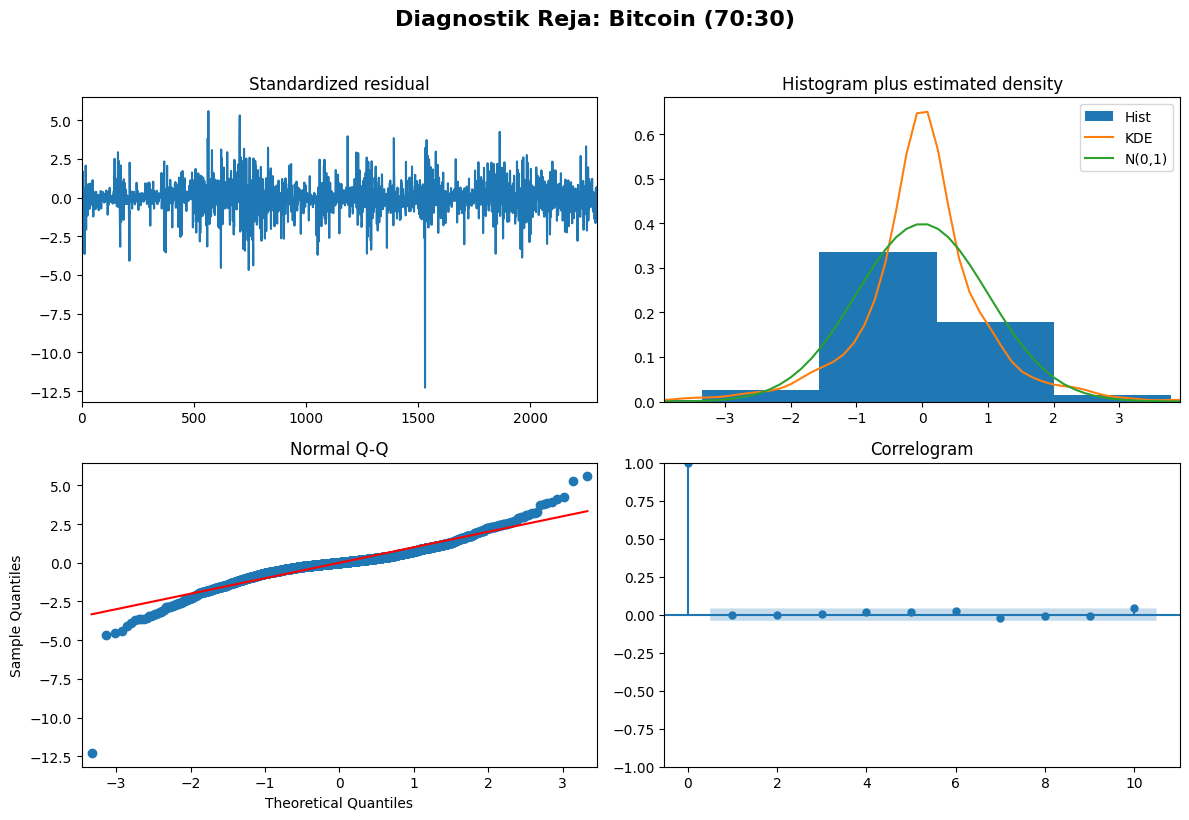


==================== DIAGNOSTICS: Emas (70:30) ====================


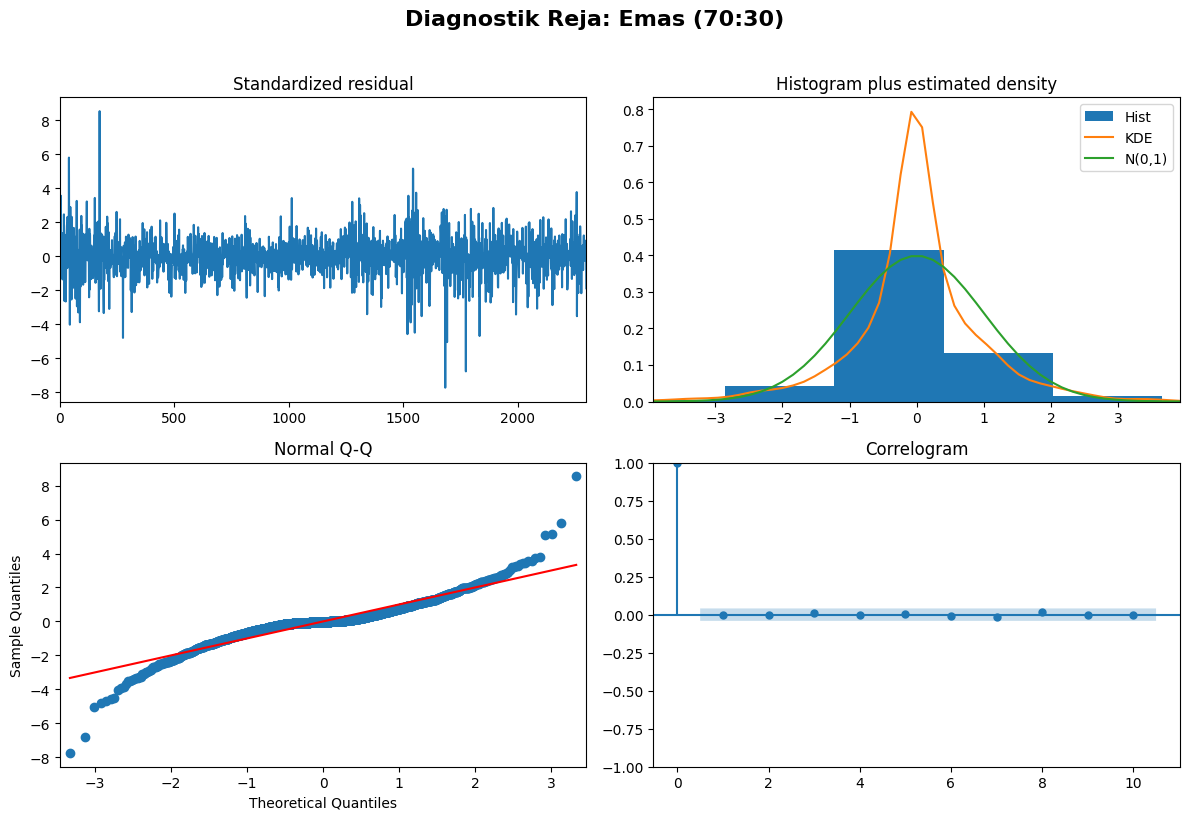


==================== DIAGNOSTICS: Bitcoin (75:25) ====================


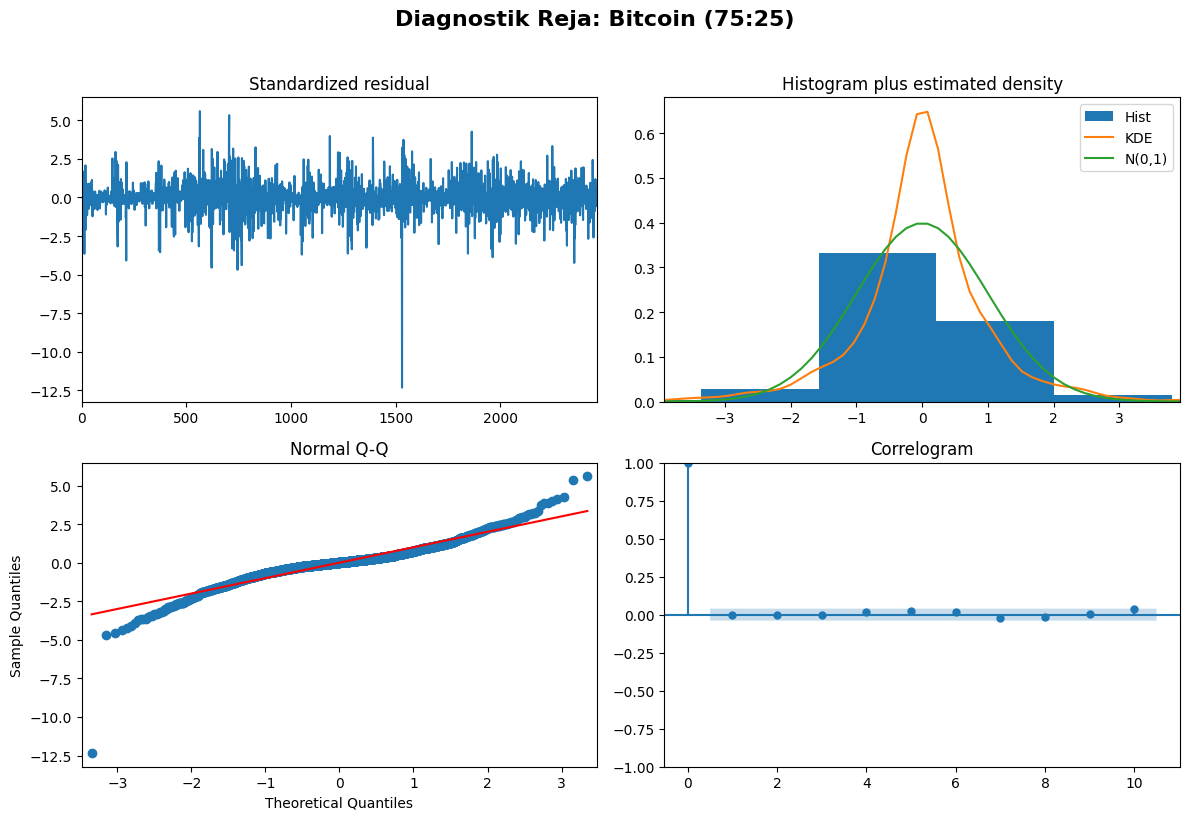


==================== DIAGNOSTICS: Emas (75:25) ====================


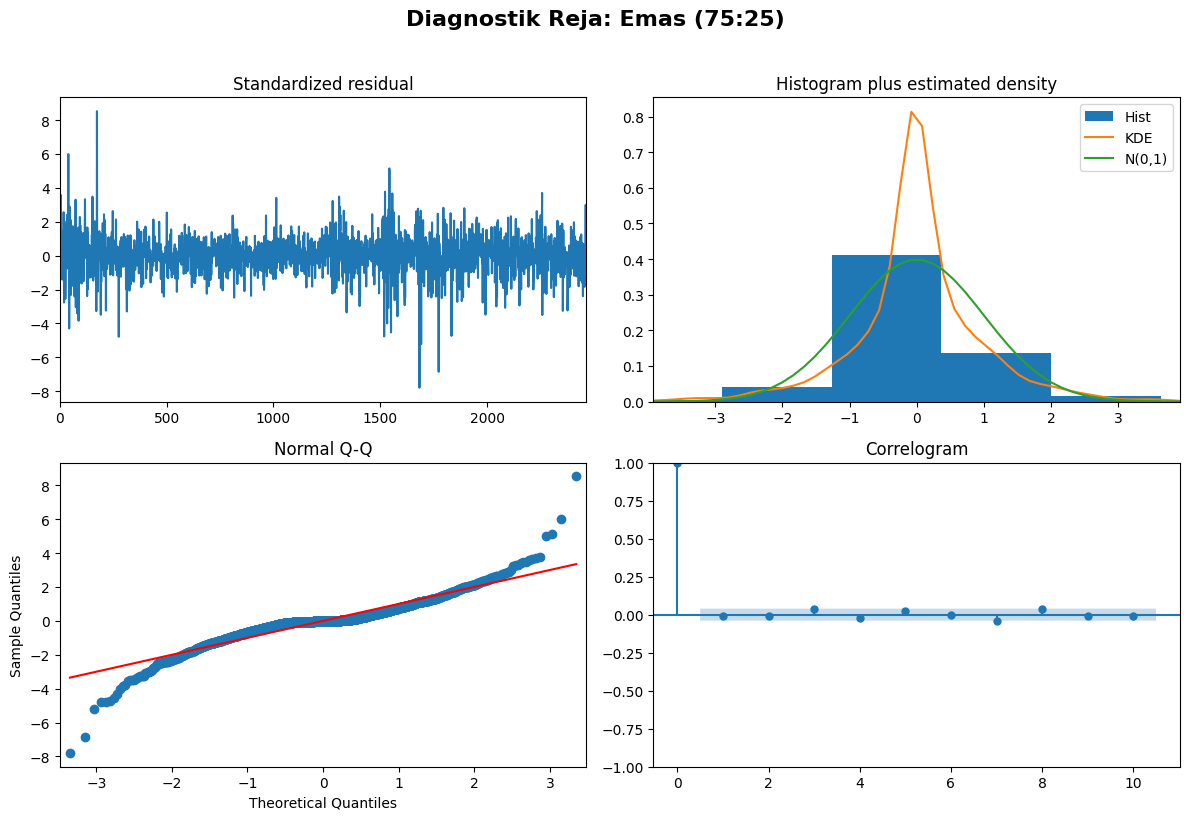


==================== DIAGNOSTICS: Bitcoin (80:20) ====================


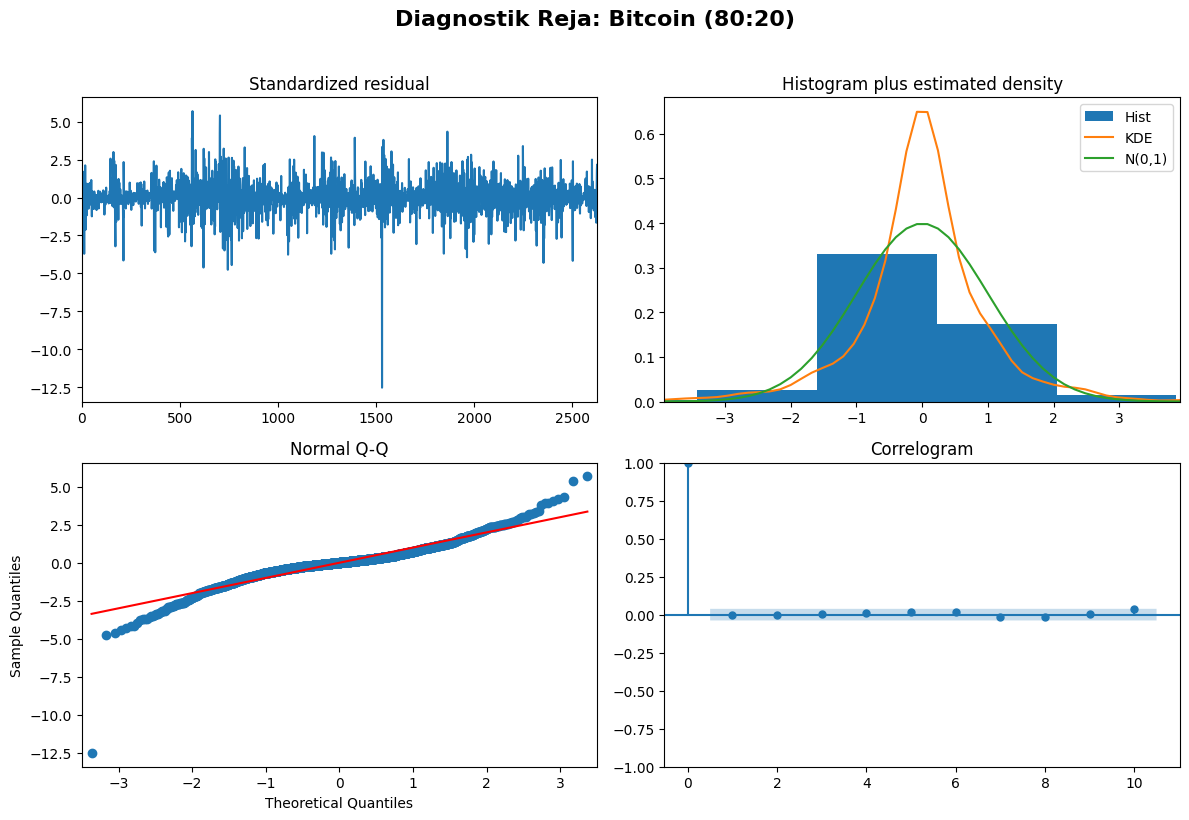


==================== DIAGNOSTICS: Emas (80:20) ====================


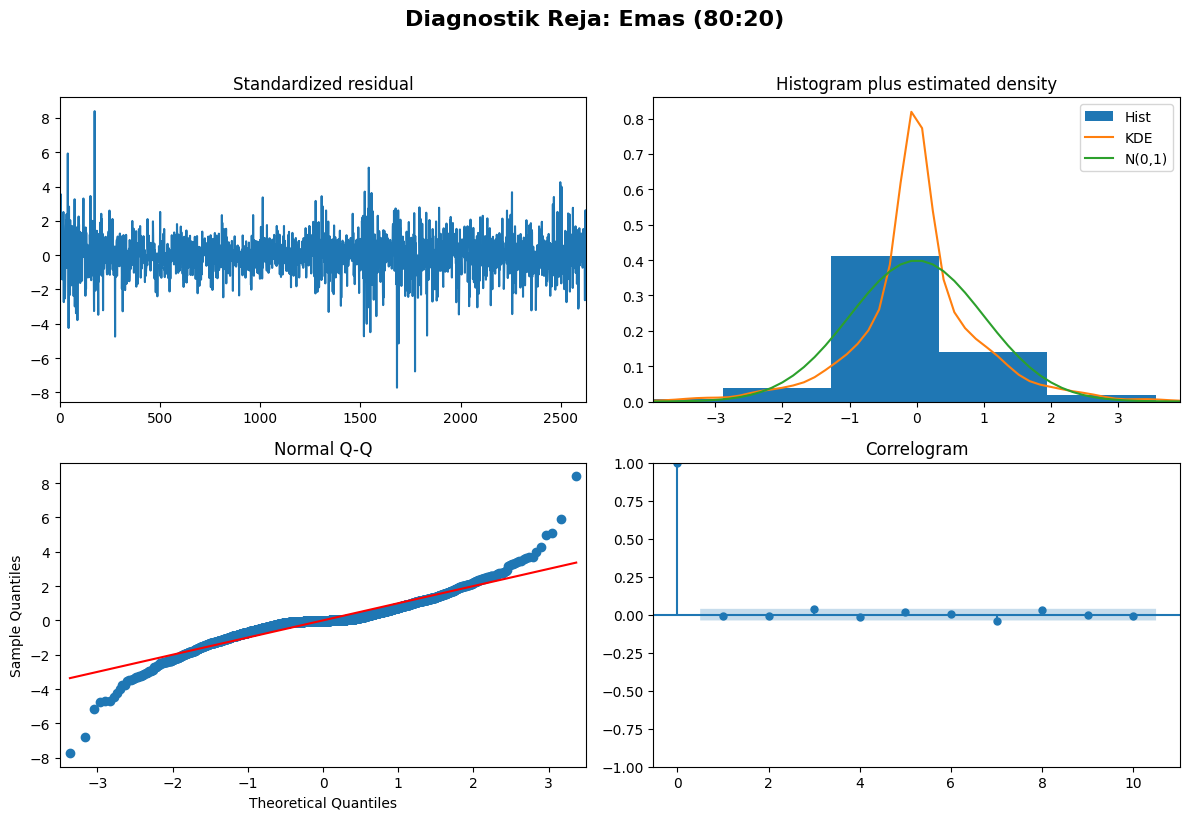

In [45]:
import matplotlib.pyplot as plt

# --- 1. Define the Diagnostic Function ---
def show_diagnostics(model, title):
    """
    Generates the standard 4-plot diagnostic summary for a given ARIMA model.
    Includes: Reja Piawai, Histogram/KDE, Plot Q-Q , and Korrelogram (ACF).
    """
    print(f"\n{'='*20} DIAGNOSTICS: {title} {'='*20}")

    # plot_diagnostics is a built-in method in pmdarima/statsmodels
    fig = model.plot_diagnostics(figsize=(12, 8))

    # Add a main title to the figure so you know which model it is
    fig.suptitle(f"Diagnostik Reja: {title}", fontsize=16, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

# --- 2. Run Diagnostics for All 6 Configurations ---

# === 70:30 SPLIT ===
show_diagnostics(model_btc_70, "Bitcoin (70:30)")
show_diagnostics(model_gold_70, "Emas (70:30)")

# === 75:25 SPLIT ===
show_diagnostics(model_btc_75, "Bitcoin (75:25)")
show_diagnostics(model_gold_75, "Emas (75:25)")

# === 80:20 SPLIT ===
show_diagnostics(model_btc_80, "Bitcoin (80:20)")
show_diagnostics(model_gold_80, "Emas (80:20)")

#ljung Box and Jarque Bera

In [46]:
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

def run_residual_tests(models_dict):
    """
    Runs Ljung-Box and Jarque-Bera tests on a dictionary of {Name: Model_Object}.
    Returns a DataFrame summary.
    """
    results_list = []

    for name, model in models_dict.items():
        # 1. Get Residuals
        residuals = model.resid()

        # 2. Ljung-Box Test (checking for autocorrelation up to lag 10)
        # We want p-value > 0.05 to confirm "White Noise" (No patterns left)
        lb_df = acorr_ljungbox(residuals, lags=[10], return_df=True)
        lb_stat = lb_df['lb_stat'].values[0]
        lb_pvalue = lb_df['lb_pvalue'].values[0]

        # 3. Jarque-Bera Test (checking for Normality)
        # We want p-value > 0.05 to confirm "Normal Distribution"
        jb_stat, jb_pvalue = jarque_bera(residuals)

        # 4. Append to list
        results_list.append({
            'Model Name': name,
            'Ljung-Box (Stat)': round(lb_stat, 4),
            'Ljung-Box (p-val)': round(lb_pvalue, 4),
            'Jarque-Bera (Stat)': round(jb_stat, 4),
            'Jarque-Bera (p-val)': round(jb_pvalue, 4),
            'Normality': "Normal" if jb_pvalue > 0.05 else "Not Normal",
            'White Noise': "Yes" if lb_pvalue > 0.05 else "No (Pattern Left)"
        })

    return pd.DataFrame(results_list)

# --- Define your models in a dictionary ---
all_models = {
    "Bitcoin (70:30)": model_btc_70,
    "Gold (70:30)": model_gold_70,
    "Bitcoin (75:25)": model_btc_75,
    "Gold (75:25)": model_gold_75,
    "Bitcoin (80:20)": model_btc_80,
    "Gold (80:20)": model_gold_80
}

# --- Run the function ---
test_results = run_residual_tests(all_models)

# --- Display the Table ---
print("Statistical Diagnostic Tests (Ljung-Box & Jarque-Bera)")
print(test_results.to_string(index=False))

Statistical Diagnostic Tests (Ljung-Box & Jarque-Bera)
     Model Name  Ljung-Box (Stat)  Ljung-Box (p-val)  Jarque-Bera (Stat)  Jarque-Bera (p-val)  Normality White Noise
Bitcoin (70:30)            8.4167             0.5882          15465.3116                  0.0 Not Normal         Yes
   Gold (70:30)            1.7759             0.9978           6098.3714                  0.0 Not Normal         Yes
Bitcoin (75:25)            7.7837             0.6500          15388.7328                  0.0 Not Normal         Yes
   Gold (75:25)           14.7208             0.1426           6207.7424                  0.0 Not Normal         Yes
Bitcoin (80:20)            6.6866             0.7547          16812.3250                  0.0 Not Normal         Yes
   Gold (80:20)           12.6372             0.2447           5728.5783                  0.0 Not Normal         Yes


# ARCH-LM Test

In [47]:
import pandas as pd
from statsmodels.stats.diagnostic import het_arch

def run_arch_lm_test(models_dict, lags=10):
    """
    Runs the ARCH-LM test on the residuals of ARIMA models to check for
    conditional heteroscedasticity (volatility clustering).
    """
    results_list = []

    for name, model in models_dict.items():
        # 1. Get Squared Residuals
        # ARCH test actually checks if squared residuals are correlated
        residuals = model.resid()

        # 2. Run ARCH-LM Test
        # Returns: (Lagrange multiplier test statistic, p-value, f-value, f p-value)
        # We generally focus on the second value (LM p-value)
        test_output = het_arch(residuals, ddof=0, maxlag=lags)

        lm_stat = test_output[0]
        lm_pvalue = test_output[1]

        # 3. Append results
        results_list.append({
            'Model Name': name,
            'Lag': lags,
            'LM Statistic': round(lm_stat, 4),
            'P-Value': round(lm_pvalue, 4),
            'ARCH Effect?': "Yes (Use GARCH)" if lm_pvalue < 0.05 else "No (Constant Vol)"
        })

    return pd.DataFrame(results_list)

# --- Define your models (Reuse the dictionary if you have it) ---
all_models = {
    "Bitcoin (70:30)": model_btc_70,
    "Gold (70:30)": model_gold_70,
    "Bitcoin (75:25)": model_btc_75,
    "Gold (75:25)": model_gold_75,
    "Bitcoin (80:20)": model_btc_80,
    "Gold (80:20)": model_gold_80
}

# --- Execute ---
arch_results = run_arch_lm_test(all_models, lags=10)

print("ARCH-LM Test Results (Checking for Volatility Clustering)")
print(arch_results.to_string(index=False))

ARCH-LM Test Results (Checking for Volatility Clustering)
     Model Name  Lag  LM Statistic  P-Value    ARCH Effect?
Bitcoin (70:30)   10       40.9907      0.0 Yes (Use GARCH)
   Gold (70:30)   10       87.1927      0.0 Yes (Use GARCH)
Bitcoin (75:25)   10       43.5351      0.0 Yes (Use GARCH)
   Gold (75:25)   10       93.5558      0.0 Yes (Use GARCH)
Bitcoin (80:20)   10       49.6548      0.0 Yes (Use GARCH)
   Gold (80:20)   10       95.4353      0.0 Yes (Use GARCH)


# ARIMA-GARCH

In [48]:
%pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 9.8 MB/s eta 0:00:00


In [49]:
import pandas as pd
from arch import arch_model

# --- 1. Pastikan Model ARIMA Dah Ada ---
# (Kita kumpul balik model ARIMA yang awak dah run tadi ke dalam dictionary)
all_arima_models = {
    "Bitcoin (70:30)": model_btc_70,
    "Gold (70:30)": model_gold_70,
    "Bitcoin (75:25)": model_btc_75,
    "Gold (75:25)": model_gold_75,
    "Bitcoin (80:20)": model_btc_80,
    "Gold (80:20)": model_gold_80
}

# --- 2. Define Function ---
def fit_compare_and_show_winners(arima_models_dict):
    comparison_list = []
    winning_models = {}

    print(f"{'='*20} COMPARING GARCH(1,1) vs GARCH(2,2) WITH BIC {'='*20}")

    for name, arima_model in arima_models_dict.items():
        print(f"Processing: {name}...")

        # 1. Extract Residuals (Already scaled *100 from ARIMA)
        residuals = arima_model.resid()

        # --- MODEL A: GARCH(1,1) ---
        garch11 = arch_model(residuals, vol='Garch', p=1, q=1, dist='t', mean='Zero')
        res11 = garch11.fit(disp='off')

        # --- MODEL B: GARCH(2,2) ---
        garch22 = arch_model(residuals, vol='Garch', p=2, q=2, dist='t', mean='Zero')
        res22 = garch22.fit(disp='off')

        # 3. Compare AIC (Lower is Better)
        # We also collect BIC now as requested
        if res11.aic < res22.aic:
            winner_label = "GARCH(1,1)"
            winning_models[name] = res11
        else:
            winner_label = "GARCH(2,2)"
            winning_models[name] = res22

        # 4. Store stats for the Comparison Table
        comparison_list.append({
            'Asset/Split': name,
            'GARCH(1,1) AIC': round(res11.aic, 2),
            'GARCH(1,1) BIC': round(res11.bic, 2),
            'GARCH(2,2) AIC': round(res22.aic, 2),
            'GARCH(2,2) BIC': round(res22.bic, 2),
            'WINNER': winner_label
        })

    # --- 5. Display Comparison Table ---
    comp_df = pd.DataFrame(comparison_list)
    print("\n" + "="*60)
    print("      MODEL SELECTION TABLE (AIC & BIC)      ")
    print("="*60)
    print(comp_df.to_string(index=False))

    # --- 6. Display Full Summary for WINNERS only ---
    print("\n" + "="*60)
    print("      FULL PARAMETERS OF PICKED WINNING MODELS      ")
    print("="*60)

    for name, model in winning_models.items():
        print(f"\n>>> WINNER FOR {name}")
        print(model.summary())
        print("-" * 50)

    return winning_models, comp_df

# --- 3. Execute ---
garch_models, comparison_table = fit_compare_and_show_winners(all_arima_models)

==================== COMPARING GARCH(1,1) vs GARCH(2,2) WITH BIC ====================
Processing: Bitcoin (70:30)...
Processing: Gold (70:30)...
Processing: Bitcoin (75:25)...
Processing: Gold (75:25)...
Processing: Bitcoin (80:20)...
Processing: Gold (80:20)...

      MODEL SELECTION TABLE (AIC & BIC)      
    Asset/Split  GARCH(1,1) AIC  GARCH(1,1) BIC  GARCH(2,2) AIC  GARCH(2,2) BIC     WINNER
Bitcoin (70:30)        11996.02        12018.99        11999.83        12034.27 GARCH(1,1)
   Gold (70:30)         4383.43         4406.39         4384.23         4418.67 GARCH(1,1)
Bitcoin (75:25)        12875.86        12899.10        12878.77        12913.63 GARCH(1,1)
   Gold (75:25)         4699.14         4722.38         4700.11         4734.97 GARCH(1,1)
Bitcoin (80:20)        13622.48        13645.98        13624.34        13659.58 GARCH(1,1)
   Gold (80:20)         5091.69         5115.18         5092.24         5127.49 GARCH(1,1)

      FULL PARAMETERS OF PICKED WINNING MODELS      

In [50]:
import pandas as pd
import numpy as np
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# ========================================================
# PART 1: RE-COLLECT MODELS & FIT GARCH
# ========================================================

# 1. Define the dictionary of your fitted ARIMA models
# (This assumes you have already run the ARIMA fitting code for these variables)
if 'model_btc_70' in locals():
    all_models = {
        "Bitcoin (70:30)": model_btc_70, "Gold (70:30)": model_gold_70,
        "Bitcoin (75:25)": model_btc_75, "Gold (75:25)": model_gold_75,
        "Bitcoin (80:20)": model_btc_80, "Gold (80:20)": model_gold_80
    }
else:
    print("CRITICAL ERROR: Your ARIMA models (model_btc_70, etc.) are missing from memory.")
    print("Please go back and re-run the 'fit_and_print_arima' code block first!")
    all_models = {}

# 2. Re-Fit GARCH(1,1) to recreate 'garch_models'
garch_models = {}
print(f"{'='*20} RE-FITTING GARCH(1,1) {'='*20}")

for name, arima_model in all_models.items():
    print(f"Fitting GARCH for: {name}...")
    # Extract Residuals
    residuals = arima_model.resid()

    # Fit GARCH(1,1) with Student's t
    garch_spec = arch_model(residuals, vol='Garch', p=1, q=1, dist='t', mean='Zero')
    garch_models[name] = garch_spec.fit(disp='off')

# ========================================================
# PART 2: CALCULATE ACCURACY (RMSE, MAE, MAPE)
# ========================================================

def compare_forecast_accuracy(model_dict, test_data_dict):
    performance_list = []

    print(f"\n{'='*20} FINAL FORECAST ACCURACY {'='*20}")

    for name, garch_res in model_dict.items():
        # 1. Get Actual Test Data
        if "Bitcoin" in name:
            actual_log_ret = test_data_dict[name]['Bitcoin_logret'] * 100
        else:
            actual_log_ret = test_data_dict[name]['Gold_logret'] * 100

        # 2. Forecast Volatility
        n_forecast = len(actual_log_ret)
        forecasts = garch_res.forecast(horizon=n_forecast, method='simulation')
        pred_volatility = np.sqrt(forecasts.variance.values[-1, :])

        # 3. Define Proxy for Actual Volatility (|Rt|)
        actual_vol_proxy = np.abs(actual_log_ret)

        # 4. Calculate Metrics
        rmse = np.sqrt(mean_squared_error(actual_vol_proxy, pred_volatility))
        mae = mean_absolute_error(actual_vol_proxy, pred_volatility)
        mape = mean_absolute_percentage_error(actual_vol_proxy, pred_volatility) * 100

        performance_list.append({
            'Model Name': name,
            'RMSE': round(rmse, 4),
            'MAE': round(mae, 4),
            'MAPE (%)': round(mape, 2)
        })

    return pd.DataFrame(performance_list)

# Define Test Sets Mapping
test_sets = {
    "Bitcoin (70:30)": test_data, "Gold (70:30)": test_data,
    "Bitcoin (75:25)": test75_data, "Gold (75:25)": test75_data,
    "Bitcoin (80:20)": test_data_80, "Gold (80:20)": test_data_80
}

# Run Comparison
if all_models:
    final_table = compare_forecast_accuracy(garch_models, test_sets)
    print("\n--- Final Leaderboard (Sorted by RMSE - Lower is Better) ---")
    print(final_table.sort_values(by='RMSE').to_string(index=False))

==================== RE-FITTING GARCH(1,1) ====================
Fitting GARCH for: Bitcoin (70:30)...
Fitting GARCH for: Gold (70:30)...
Fitting GARCH for: Bitcoin (75:25)...
Fitting GARCH for: Gold (75:25)...
Fitting GARCH for: Bitcoin (80:20)...
Fitting GARCH for: Gold (80:20)...

==================== FINAL FORECAST ACCURACY ====================

--- Final Leaderboard (Sorted by RMSE - Lower is Better) ---
     Model Name   RMSE    MAE     MAPE (%)
   Gold (80:20) 1.0532 0.9638 1.757834e+17
   Gold (70:30) 1.2033 1.0890 1.948830e+17
   Gold (75:25) 1.2653 1.1680 2.078983e+17
Bitcoin (75:25) 3.8220 3.5135 1.721620e+03
Bitcoin (80:20) 5.2251 4.7099 2.206850e+03
Bitcoin (70:30) 6.3012 5.4364 2.323150e+03


# Diagnostik lepas check

In [51]:
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

def check_garch_residuals(garch_fitted_dict):
    """
    Performs diagnostic checks on the Standardized Residuals of fitted GARCH models.
    """
    diag_results = []

    print(f"{'='*20} GARCH MODEL DIAGNOSTICS {'='*20}")

    for name, model_res in garch_fitted_dict.items():
        # 1. Get Standardized Residuals
        # (Residuals divided by conditional volatility)
        std_resid = model_res.resid / model_res.conditional_volatility

        # Drop any NaNs (sometimes the first observation is NaN in GARCH)
        std_resid = std_resid.dropna()

        # 2. Ljung-Box Test on Standardized Residuals (Check for Linear Correlation)
        lb_test = acorr_ljungbox(std_resid, lags=[10], return_df=True)
        lb_pvalue = lb_test['lb_pvalue'].values[0]

        # 3. Ljung-Box Test on SQUARED Standardized Residuals (Check for Remaining Volatility Pattern)
        # This is critical for GARCH. If this fails, your GARCH model is bad.
        lb_sq_test = acorr_ljungbox(std_resid**2, lags=[10], return_df=True)
        lb_sq_pvalue = lb_sq_test['lb_pvalue'].values[0]

        # 4. ARCH-LM Test (Double check)
        # We test the standardized residuals. We want P-Value > 0.05 (No ARCH left).
        arch_test = het_arch(std_resid, ddof=0, maxlag=10)
        arch_lm_pvalue = arch_test[1]

        diag_results.append({
            'Model': name,
            'Ljung-Box (Standard) P-Val': round(lb_pvalue, 4),
            'Ljung-Box (Squared) P-Val': round(lb_sq_pvalue, 4),
            'ARCH-LM P-Val': round(arch_lm_pvalue, 4),
            'Verdict': "PASS" if (lb_sq_pvalue > 0.05 and arch_lm_pvalue > 0.05) else "FAIL"
        })

    return pd.DataFrame(diag_results)

# --- Execute ---
# Ensure 'garch_models' exists (from your previous fitting step)
if 'garch_models' in locals():
    diagnostics_table = check_garch_residuals(garch_models)
    print("\n--- GARCH Residual Diagnostics (Goal: P-Value > 0.05) ---")
    print(diagnostics_table.to_string(index=False))
else:
    print("Error: 'garch_models' not found. Please fit the GARCH models first.")

==================== GARCH MODEL DIAGNOSTICS ====================

--- GARCH Residual Diagnostics (Goal: P-Value > 0.05) ---
          Model  Ljung-Box (Standard) P-Val  Ljung-Box (Squared) P-Val  ARCH-LM P-Val Verdict
Bitcoin (70:30)                      0.0290                     0.9009         0.9009    PASS
   Gold (70:30)                      0.9956                     0.0005         0.0007    FAIL
Bitcoin (75:25)                      0.0470                     0.8762         0.8754    PASS
   Gold (75:25)                      0.2959                     0.0001         0.0001    FAIL
Bitcoin (80:20)                      0.0330                     0.8286         0.8273    PASS
   Gold (80:20)                      0.4069                     0.0000         0.0000    FAIL


# pred vs Actual

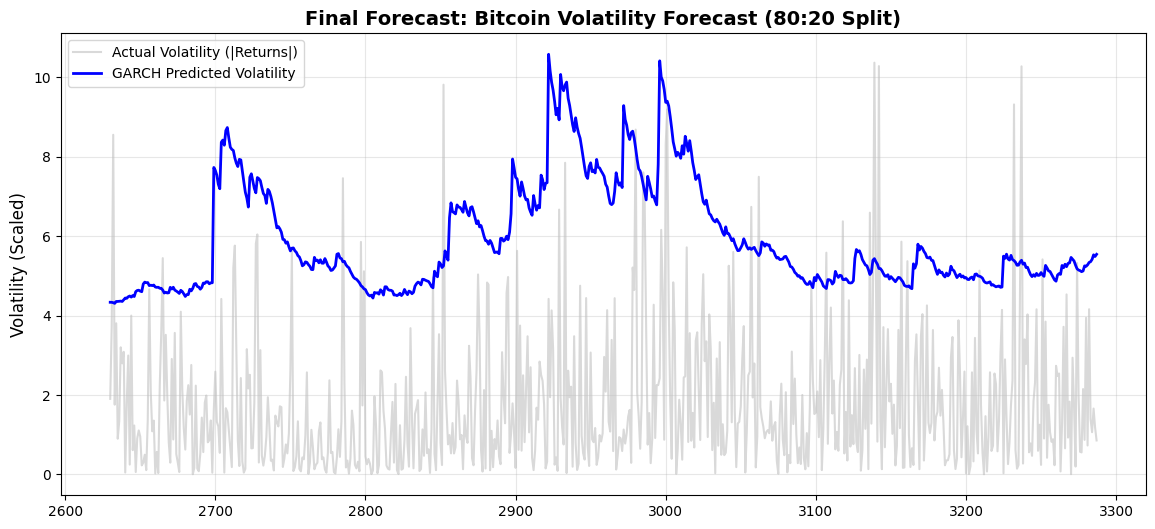

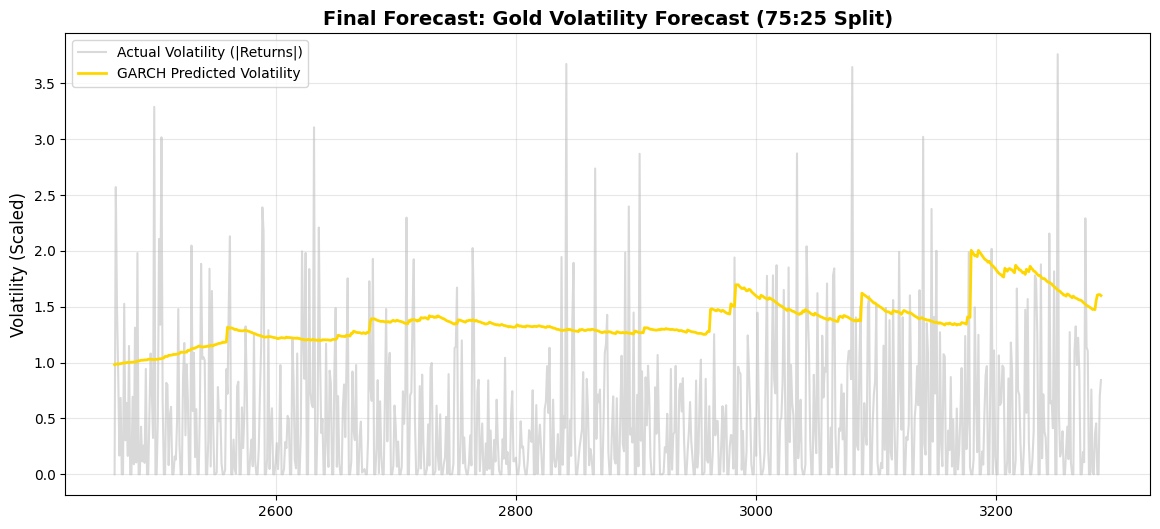

In [52]:
import matplotlib.pyplot as plt
import numpy as np

def plot_final_forecast(model_res, test_data_series, title, color):
    """
    Plots the GARCH Predicted Volatility vs. Actual Absolute Returns
    """
    # 1. Get Forecast
    n_forecast = len(test_data_series)
    forecasts = model_res.forecast(horizon=n_forecast, method='simulation')
    pred_volatility = np.sqrt(forecasts.variance.values[-1, :])

    # 2. Get Actual Volatility Proxy (Absolute Returns)
    actual_vol_proxy = np.abs(test_data_series)

    # 3. Plot
    plt.figure(figsize=(14, 6))

    # Plot Actual (Grey, faint)
    plt.plot(test_data_series.index, actual_vol_proxy, color='silver', alpha=0.6, label='Actual Volatility (|Returns|)')

    # Plot Predicted (Bright Color)
    plt.plot(test_data_series.index, pred_volatility, color=color, linewidth=2, label='GARCH Predicted Volatility')

    plt.title(f"Final Forecast: {title}", fontsize=14, fontweight='bold')
    plt.ylabel("Volatility (Scaled)", fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================
# PLOT THE WINNERS (Based on your RMSE table)
# ==========================================

# 1. Bitcoin Winner: 80:20 Split
# (Ensure 'garch_models' and 'test_data_80' are loaded from previous steps)
plot_final_forecast(
    garch_models["Bitcoin (80:20)"],
    test_data_80['Bitcoin_logret'] * 100,
    "Bitcoin Volatility Forecast (80:20 Split)",
    "blue"
)

# 2. Gold Winner: 75:25 Split
# (Ensure 'garch_models' and 'test75_data' are loaded)
plot_final_forecast(
    garch_models["Gold (75:25)"],
    test75_data['Gold_logret'] * 100,
    "Gold Volatility Forecast (75:25 Split)",
    "gold" # Gold color for Gold!
)

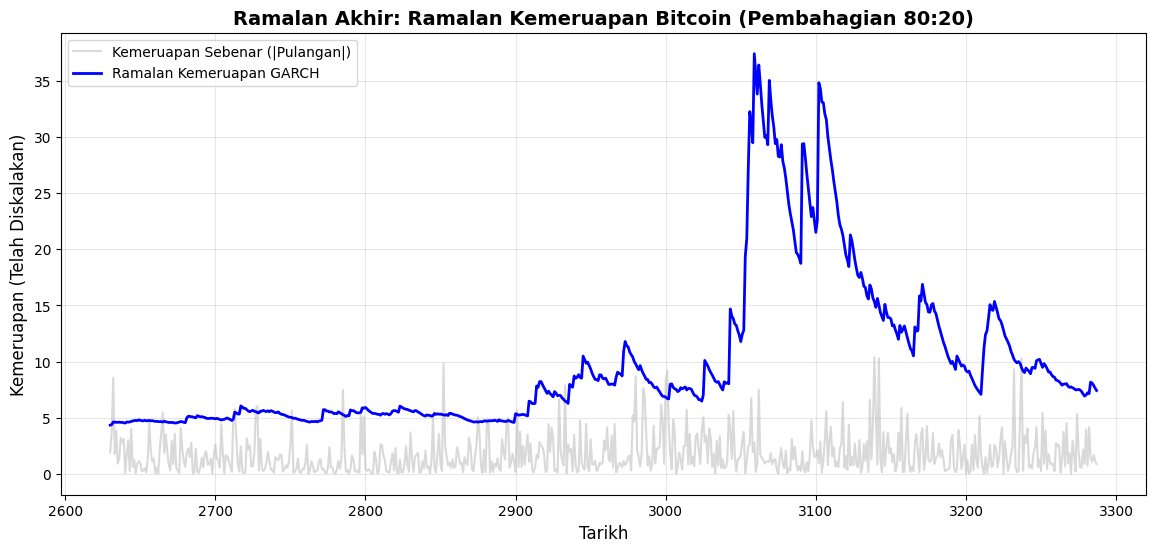

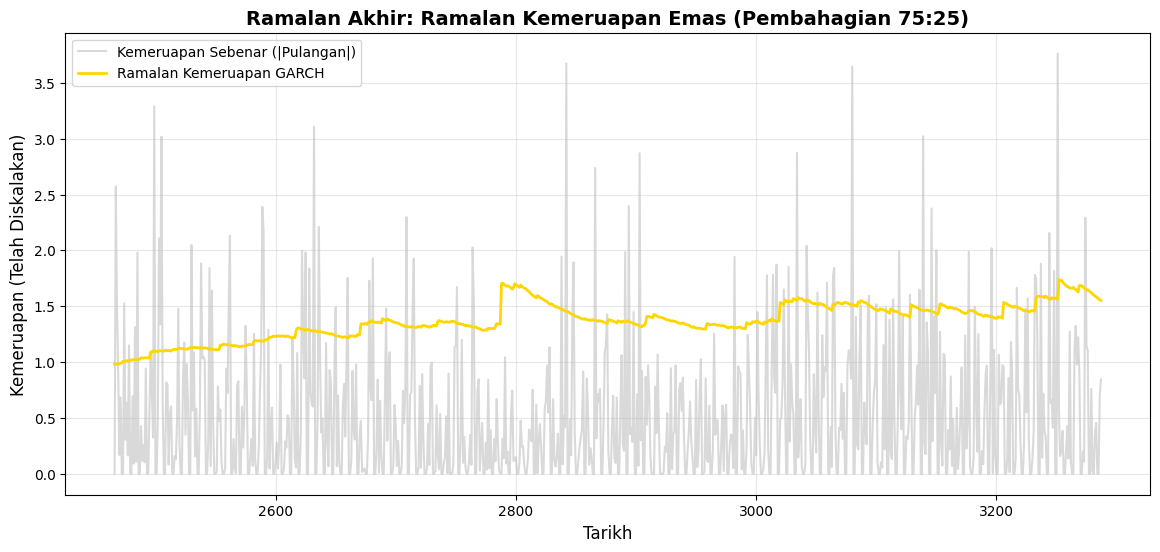

In [54]:
import matplotlib.pyplot as plt
import numpy as np

def plot_final_forecast(model_res, test_data_series, title, color):
    """
    Memplot Ramalan Kemeruapan GARCH berbanding Kemeruapan Sebenar (Pulangan Mutlak)
    """
    # 1. Dapatkan Ramalan
    n_forecast = len(test_data_series)
    forecasts = model_res.forecast(horizon=n_forecast, method='simulation')
    pred_volatility = np.sqrt(forecasts.variance.values[-1, :])

    # 2. Dapatkan Proksi Kemeruapan Sebenar (Pulangan Mutlak)
    actual_vol_proxy = np.abs(test_data_series)

    # 3. Plot
    plt.figure(figsize=(14, 6))

    # Plot Sebenar (Kelabu, pudar)
    plt.plot(test_data_series.index, actual_vol_proxy, color='silver', alpha=0.6, label='Kemeruapan Sebenar (|Pulangan|)')

    # Plot Ramalan (Warna Terang)
    plt.plot(test_data_series.index, pred_volatility, color=color, linewidth=2, label='Ramalan Kemeruapan GARCH')

    plt.title(f"Ramalan Akhir: {title}", fontsize=14, fontweight='bold')
    plt.ylabel("Kemeruapan (Telah Diskalakan)", fontsize=12)
    plt.xlabel("Tarikh", fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================
# PLOT MODEL TERBAIK
# ==========================================

# 1. Pemenang Bitcoin: Pembahagian 80:20
plot_final_forecast(
    garch_models["Bitcoin (80:20)"],
    test_data_80['Bitcoin_logret'] * 100,
    "Ramalan Kemeruapan Bitcoin (Pembahagian 80:20)",
    "blue"
)

# 2. Pemenang Emas: Pembahagian 75:25
plot_final_forecast(
    garch_models["Gold (75:25)"],
    test75_data['Gold_logret'] * 100,
    "Ramalan Kemeruapan Emas (Pembahagian 75:25)",
    "gold"
)

# Multivariate LSTM


RUNNING: Target=Bitcoin | Split=70:30
Train Shape: (2279, 30, 2) | Test Shape: (978, 30, 2)
RESULTS (70:30): RMSE=9988.68, MAE=7265.00, MAPE=4.31%


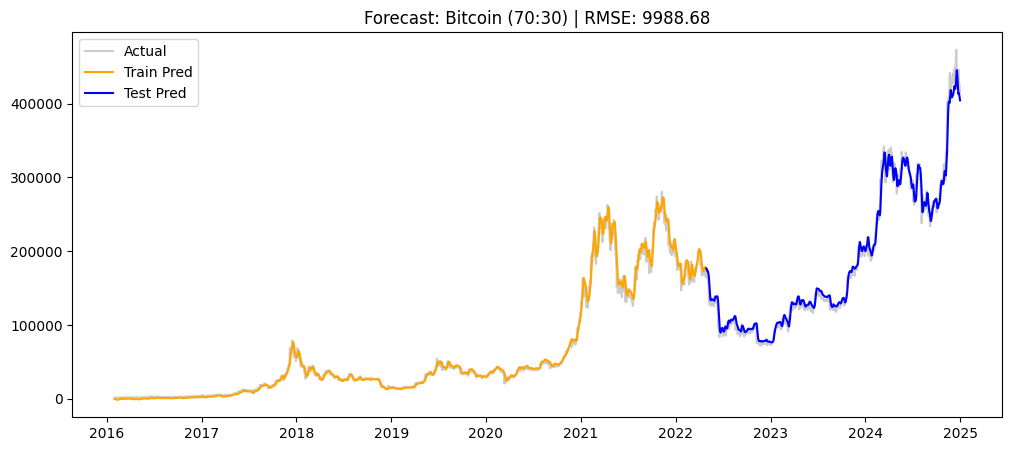


RUNNING: Target=Bitcoin | Split=75:25
Train Shape: (2442, 30, 2) | Test Shape: (815, 30, 2)
RESULTS (75:25): RMSE=10955.64, MAE=7905.97, MAPE=4.20%


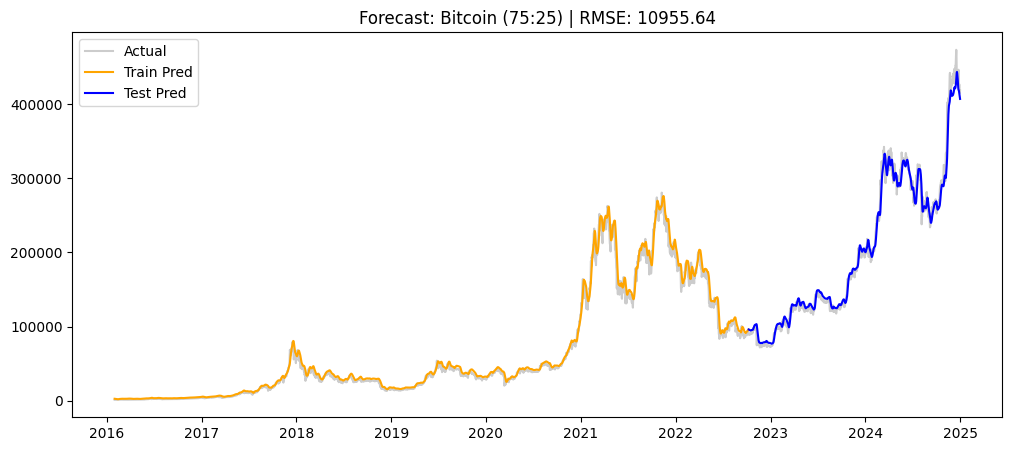


RUNNING: Target=Bitcoin | Split=80:20
Train Shape: (2605, 30, 2) | Test Shape: (652, 30, 2)
RESULTS (80:20): RMSE=13266.81, MAE=9561.35, MAPE=4.07%


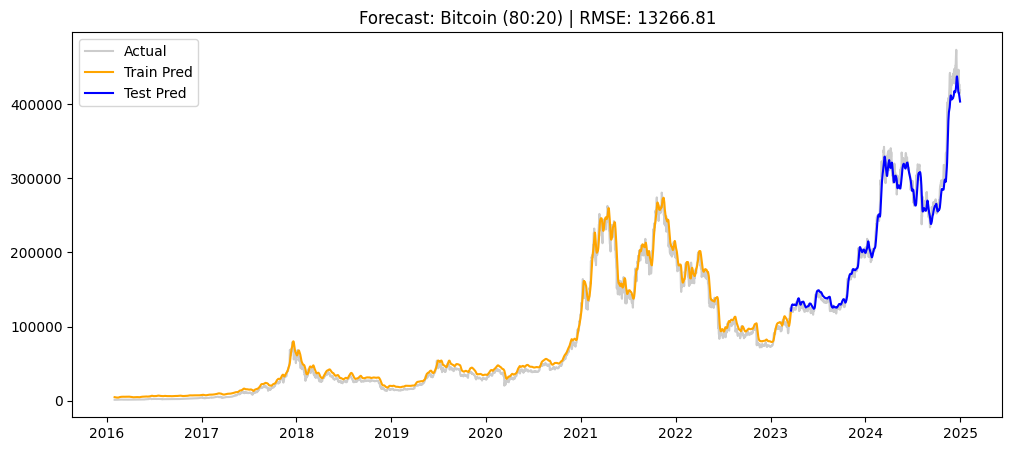


RUNNING: Target=Gold | Split=70:30
Train Shape: (2279, 30, 2) | Test Shape: (978, 30, 2)
RESULTS (70:30): RMSE=191.52, MAE=143.17, MAPE=1.49%


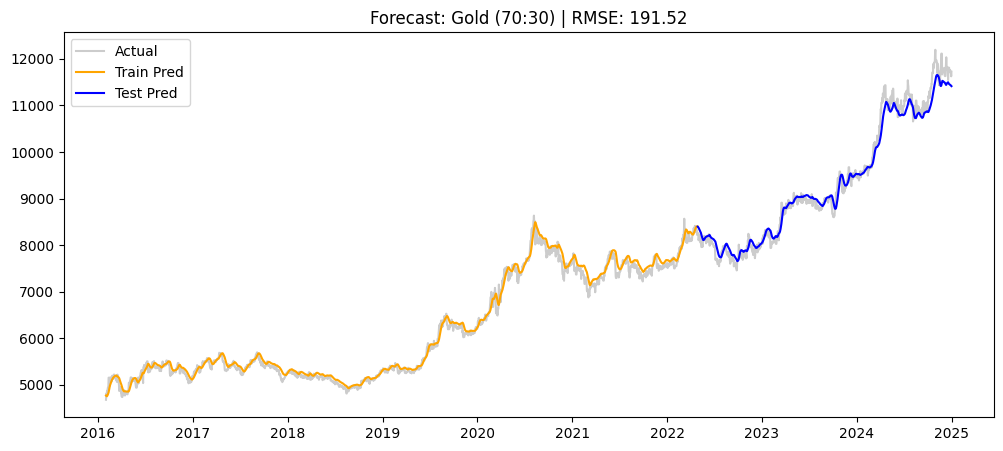


RUNNING: Target=Gold | Split=75:25
Train Shape: (2442, 30, 2) | Test Shape: (815, 30, 2)
RESULTS (75:25): RMSE=189.82, MAE=136.15, MAPE=1.35%


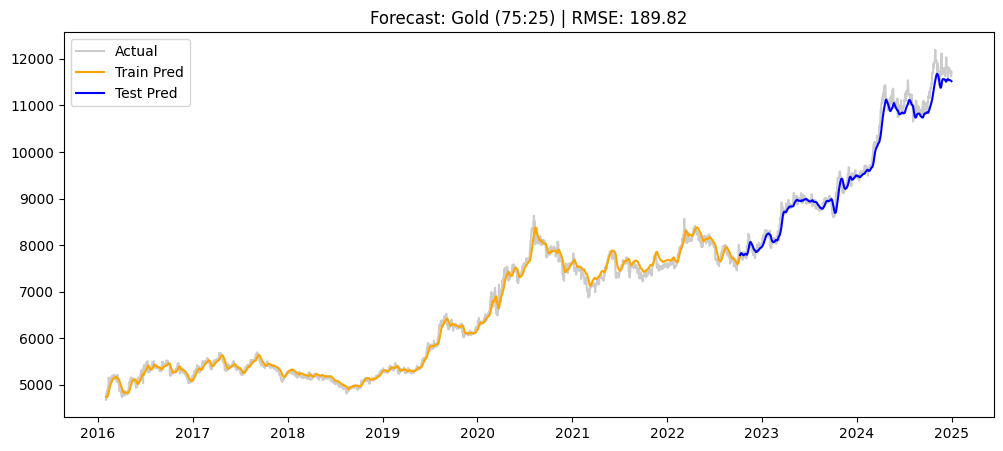


RUNNING: Target=Gold | Split=80:20
Train Shape: (2605, 30, 2) | Test Shape: (652, 30, 2)
RESULTS (80:20): RMSE=333.20, MAE=276.96, MAPE=2.62%


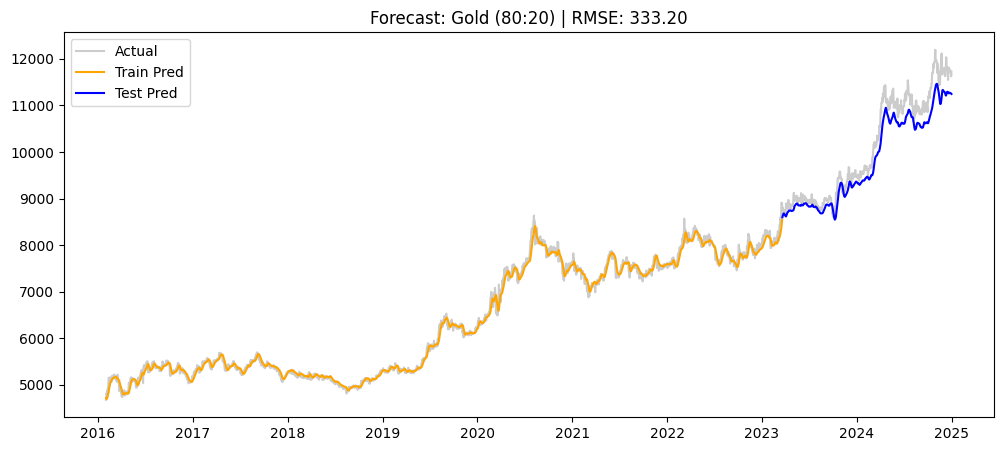


=== FINAL MULTIVARIATE LSTM RESULTS ===


,Target,Split,RMSE,MAE,MAPE (%)
0,Bitcoin,70:30,9988.676741,7264.996184,4.311909
1,Bitcoin,75:25,10955.641524,7905.967524,4.200495
2,Bitcoin,80:20,13266.811066,9561.346134,4.074148
4,Gold,75:25,189.824849,136.150915,1.347782
3,Gold,70:30,191.520368,143.166998,1.485377
5,Gold,80:20,333.195821,276.955849,2.622615


In [ ]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ======================================================
# 1. SETUP & HELPER FUNCTIONS
# ======================================================

# Ensure 'merged' dataframe exists from your previous steps
# df = merged.copy()

def make_sequences(data, target_col_idx, window_size):
    """
    Creates sequences for LSTM.
    data: Scaled 2D array (samples, features)
    target_col_idx: 0 for Bitcoin, 1 for Gold
    """
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :]) # All features
        y.append(data[i, target_col_idx])  # Specific target column
    return np.array(X), np.array(y)

def inverse_transform_target(y_scaled, scaler_obj, target_col_idx):
    """
    Inverse transforms a single column (target) using the multi-column scaler.
    """
    n_features = scaler_obj.n_features_in_
    # Create a dummy array with the correct shape
    dummy = np.zeros((len(y_scaled), n_features))
    # Place the scaled target in the correct column
    dummy[:, target_col_idx] = y_scaled.flatten()
    # Inverse transform
    inversed = scaler_obj.inverse_transform(dummy)
    # Return only the target column
    return inversed[:, target_col_idx]

def run_lstm_config(df, target_col, split_ratio, split_name):
    print(f"\n{'='*40}")
    print(f"RUNNING: Target={target_col} | Split={split_name}")
    print(f"{'='*40}")

    # 1. Setup
    feature_cols = ['Bitcoin', 'Gold']
    target_col_idx = feature_cols.index(target_col) # 0 for BTC, 1 for Gold
    date_col = 'Date'
    window_size = 30

    # 2. Scaling
    data_values = df[feature_cols].values
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data_values)

    # 3. Create Sequences
    X, y = make_sequences(scaled_data, target_col_idx, window_size)

    # 4. Split
    train_size = int(len(X) * split_ratio)
    X_train, y_train = X[:train_size], y[:train_size]
    X_test, y_test = X[train_size:], y[train_size:]

    print(f"Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")

    # 5. Build Model
    tf.random.set_seed(42)
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(window_size, len(feature_cols))),
        Dropout(0.1),
        LSTM(32),
        Dropout(0.1),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')

    # 6. Train
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=50,
        batch_size=32,
        callbacks=[es],
        verbose=0 # Silent training to keep output clean
    )

    # 7. Predictions & Inverse Transform
    y_pred_train_scaled = model.predict(X_train, verbose=0)
    y_pred_test_scaled = model.predict(X_test, verbose=0)

    y_train_inv = inverse_transform_target(y_train, scaler, target_col_idx)
    y_test_inv = inverse_transform_target(y_test, scaler, target_col_idx)
    pred_train_inv = inverse_transform_target(y_pred_train_scaled, scaler, target_col_idx)
    pred_test_inv = inverse_transform_target(y_pred_test_scaled, scaler, target_col_idx)

    # 8. Metrics
    rmse = np.sqrt(mean_squared_error(y_test_inv, pred_test_inv))
    mae = mean_absolute_error(y_test_inv, pred_test_inv)
    mape = np.mean(np.abs((y_test_inv - pred_test_inv) / y_test_inv)) * 100

    print(f"RESULTS ({split_name}): RMSE={rmse:.2f}, MAE={mae:.2f}, MAPE={mape:.2f}%")

    # 9. Plotting
    # Prepare dates for plotting
    dates = df[date_col].iloc[window_size:]
    train_dates = dates.iloc[:train_size]
    test_dates = dates.iloc[train_size:]

    plt.figure(figsize=(12, 5))
    plt.plot(dates, df[target_col].iloc[window_size:], label='Actual', color='gray', alpha=0.4)
    plt.plot(train_dates, pred_train_inv, label='Train Pred', color='orange')
    plt.plot(test_dates, pred_test_inv, label='Test Pred', color='blue')
    plt.title(f"Forecast: {target_col} ({split_name}) | RMSE: {rmse:.2f}")
    plt.legend()
    plt.show()

    # Return metrics for summary table
    return {
        "Target": target_col,
        "Split": split_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape
    }

# ======================================================
# 2. RUN EXPERIMENTS LOOP
# ======================================================

# Configuration List
splits = [
    (0.70, "70:30"),
    (0.75, "75:25"),
    (0.80, "80:20")
]

targets = ["Bitcoin", "Gold"]
all_results = []

# Loop through every combination
for target in targets:
    for ratio, name in splits:
        res = run_lstm_config(merged, target, ratio, name)
        all_results.append(res)

# ======================================================
# 3. FINAL SUMMARY TABLE
# ======================================================
results_df = pd.DataFrame(all_results)
print("\n=== FINAL MULTIVARIATE LSTM RESULTS ===")
display(results_df.sort_values(by=["Target", "RMSE"]))


MENJALANKAN: Sasaran=Bitcoin | Pembahagian=70:30
Saiz Latihan: (2279, 30, 2) | Saiz Ujian: (978, 30, 2)
KEPUTUSAN (70:30): RMSE=11495.19, MAE=8587.35, MAPE=5.32%


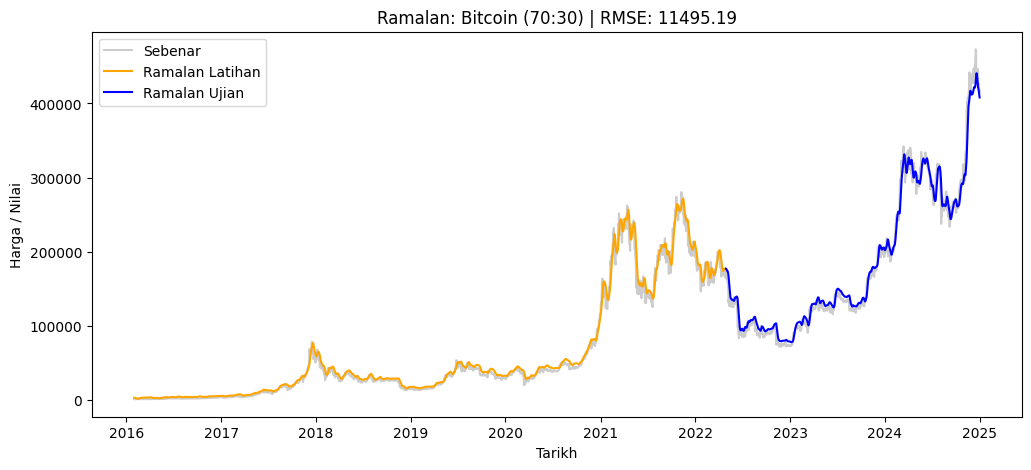


MENJALANKAN: Sasaran=Bitcoin | Pembahagian=75:25
Saiz Latihan: (2442, 30, 2) | Saiz Ujian: (815, 30, 2)
KEPUTUSAN (75:25): RMSE=13427.03, MAE=9075.17, MAPE=4.65%


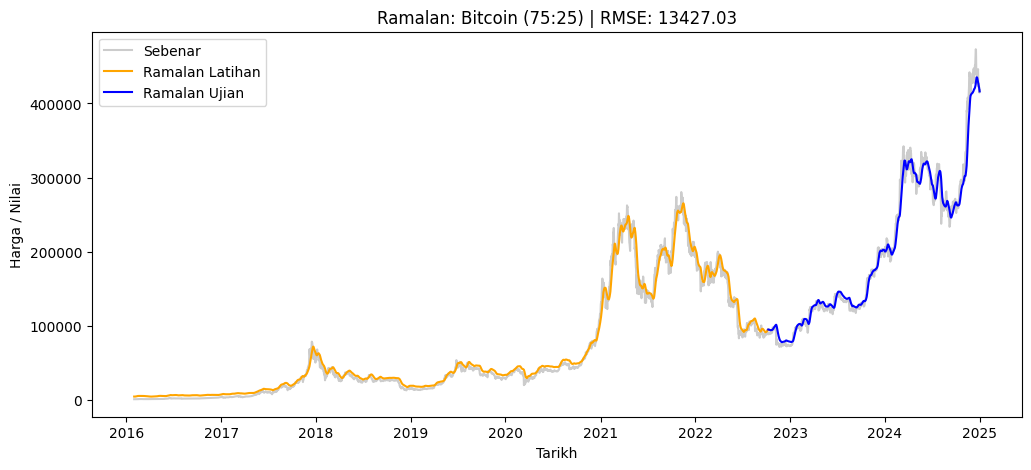


MENJALANKAN: Sasaran=Bitcoin | Pembahagian=80:20
Saiz Latihan: (2605, 30, 2) | Saiz Ujian: (652, 30, 2)
KEPUTUSAN (80:20): RMSE=14255.41, MAE=9709.87, MAPE=3.80%


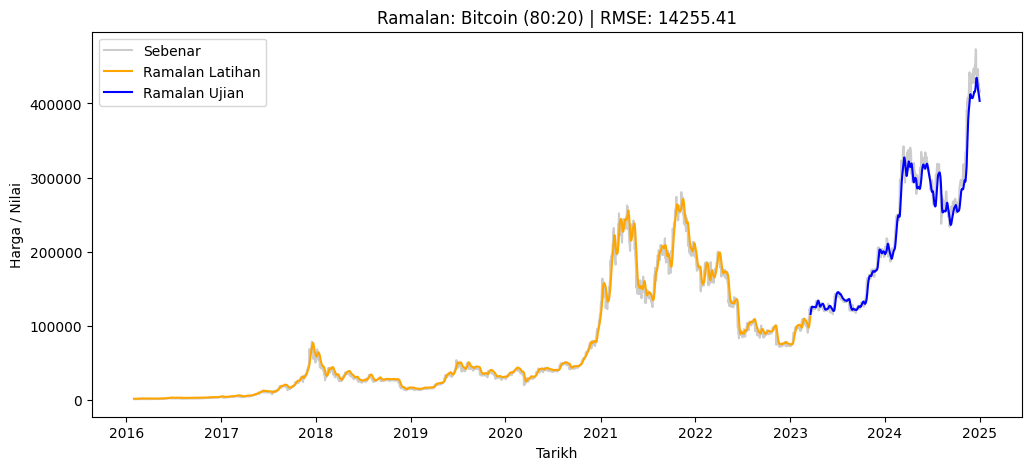


MENJALANKAN: Sasaran=Gold | Pembahagian=70:30
Saiz Latihan: (2279, 30, 2) | Saiz Ujian: (978, 30, 2)
KEPUTUSAN (70:30): RMSE=184.05, MAE=145.57, MAPE=1.55%


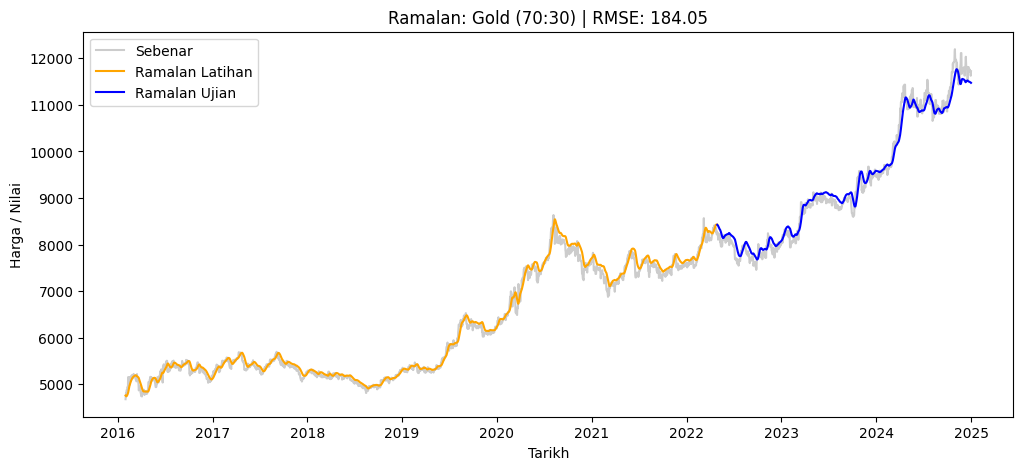


MENJALANKAN: Sasaran=Gold | Pembahagian=75:25
Saiz Latihan: (2442, 30, 2) | Saiz Ujian: (815, 30, 2)
KEPUTUSAN (75:25): RMSE=195.28, MAE=146.19, MAPE=1.47%


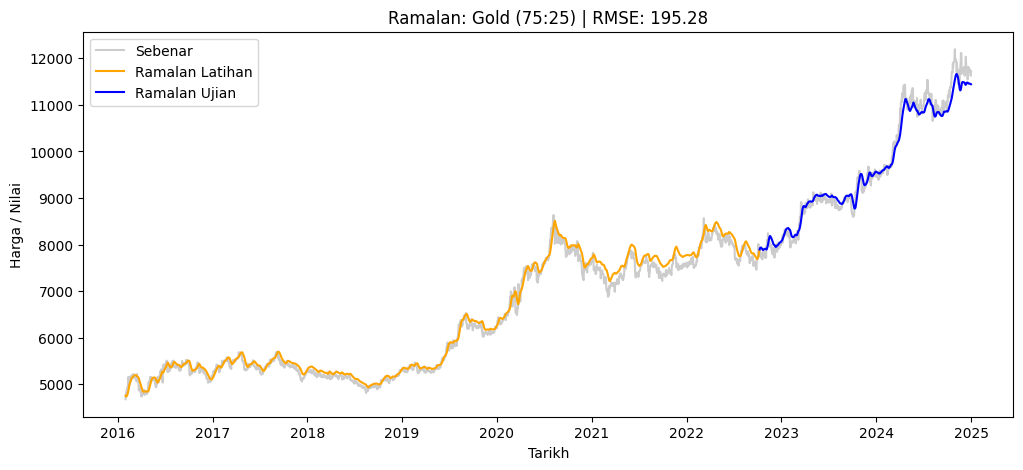


MENJALANKAN: Sasaran=Gold | Pembahagian=80:20
Saiz Latihan: (2605, 30, 2) | Saiz Ujian: (652, 30, 2)
KEPUTUSAN (80:20): RMSE=173.66, MAE=135.28, MAPE=1.33%


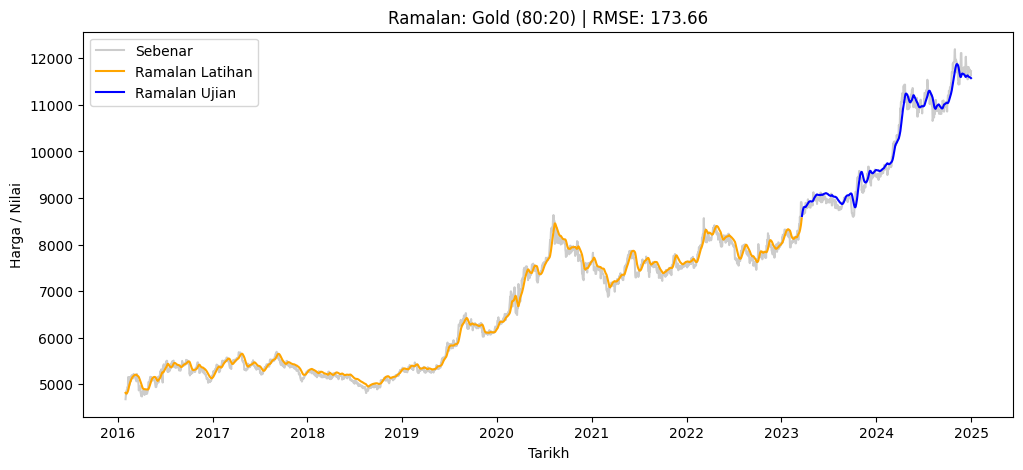


=== KEPUTUSAN AKHIR LSTM MULTIVARIAT ===


,Sasaran,Pembahagian,RMSE,MAE,MAPE (%)
0,Bitcoin,70:30,11495.189840,8587.351081,5.322282
1,Bitcoin,75:25,13427.028916,9075.165380,4.648242
2,Bitcoin,80:20,14255.412458,9709.874172,3.801849
5,Gold,80:20,173.655751,135.284301,1.331749
3,Gold,70:30,184.048329,145.565936,1.551163
4,Gold,75:25,195.281397,146.186868,1.465491


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ======================================================
# 1. PERSIAPAN & FUNGSI PEMBANTU
# ======================================================

def make_sequences(data, target_col_idx, window_size):
    """
    Membina jujukan untuk LSTM.
    data: Tatasusunan 2D yang telah diskalakan (sampel, ciri)
    target_col_idx: 0 untuk Bitcoin, 1 untuk Emas
    """
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :]) # Semua ciri (features)
        y.append(data[i, target_col_idx])  # Lajur sasaran khusus
    return np.array(X), np.array(y)

def inverse_transform_target(y_scaled, scaler_obj, target_col_idx):
    """
    Menukarkan semula data sasaran ke skala asal menggunakan objek 'scaler'.
    """
    n_features = scaler_obj.n_features_in_
    # Bina tatasusunan 'dummy' dengan dimensi yang betul
    dummy = np.zeros((len(y_scaled), n_features))
    # Letakkan data sasaran pada indeks lajur yang betul
    dummy[:, target_col_idx] = y_scaled.flatten()
    # Transformasi songsang
    inversed = scaler_obj.inverse_transform(dummy)
    # Kembalikan hanya lajur sasaran
    return inversed[:, target_col_idx]

def run_lstm_config(df, target_col, split_ratio, split_name):
    print(f"\n{'='*40}")
    print(f"MENJALANKAN: Sasaran={target_col} | Pembahagian={split_name}")
    print(f"{'='*40}")

    # 1. Persiapan
    feature_cols = ['Bitcoin', 'Gold']
    target_col_idx = feature_cols.index(target_col) # 0 untuk BTC, 1 untuk Emas
    date_col = 'Date'
    window_size = 30

    # 2. Penskalaan
    data_values = df[feature_cols].values
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data_values)

    # 3. Bina Jujukan
    X, y = make_sequences(scaled_data, target_col_idx, window_size)

    # 4. Pembahagian Data
    train_size = int(len(X) * split_ratio)
    X_train, y_train = X[:train_size], y[:train_size]
    X_test, y_test = X[train_size:], y[train_size:]

    print(f"Saiz Latihan: {X_train.shape} | Saiz Ujian: {X_test.shape}")

    # 5. Bina Model
    tf.random.set_seed(42)
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(window_size, len(feature_cols))),
        Dropout(0.1),
        LSTM(32),
        Dropout(0.1),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')

    # 6. Latihan Model
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=50,
        batch_size=32,
        callbacks=[es],
        verbose=0 # Senyap (tidak memaparkan setiap epoch)
    )

    # 7. Ramalan & Transformasi Songsang
    y_pred_train_scaled = model.predict(X_train, verbose=0)
    y_pred_test_scaled = model.predict(X_test, verbose=0)

    y_train_inv = inverse_transform_target(y_train, scaler, target_col_idx)
    y_test_inv = inverse_transform_target(y_test, scaler, target_col_idx)
    pred_train_inv = inverse_transform_target(y_pred_train_scaled, scaler, target_col_idx)
    pred_test_inv = inverse_transform_target(y_pred_test_scaled, scaler, target_col_idx)

    # 8. Metrik Penilaian
    rmse = np.sqrt(mean_squared_error(y_test_inv, pred_test_inv))
    mae = mean_absolute_error(y_test_inv, pred_test_inv)
    mape = np.mean(np.abs((y_test_inv - pred_test_inv) / y_test_inv)) * 100

    print(f"KEPUTUSAN ({split_name}): RMSE={rmse:.2f}, MAE={mae:.2f}, MAPE={mape:.2f}%")

    # 9. Pemplotan
    dates = df[date_col].iloc[window_size:]
    train_dates = dates.iloc[:train_size]
    test_dates = dates.iloc[train_size:]

    plt.figure(figsize=(12, 5))
    plt.plot(dates, df[target_col].iloc[window_size:], label='Sebenar', color='gray', alpha=0.4)
    plt.plot(train_dates, pred_train_inv, label='Ramalan Latihan', color='orange')
    plt.plot(test_dates, pred_test_inv, label='Ramalan Ujian', color='blue')
    plt.title(f"Ramalan: {target_col} ({split_name}) | RMSE: {rmse:.2f}")
    plt.xlabel("Tarikh")
    plt.ylabel("Harga / Nilai")
    plt.legend()
    plt.show()

    # Pulangkan metrik untuk jadual ringkasan
    return {
        "Sasaran": target_col,
        "Pembahagian": split_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape
    }

# ======================================================
# 2. GELUNG EKSPERIMEN
# ======================================================

splits = [
    (0.70, "70:30"),
    (0.75, "75:25"),
    (0.80, "80:20")
]

targets = ["Bitcoin", "Gold"]
all_results = []

for target in targets:
    for ratio, name in splits:
        res = run_lstm_config(merged, target, ratio, name)
        all_results.append(res)

# ======================================================
# 3. JADUAL RINGKASAN AKHIR
# ======================================================
results_df = pd.DataFrame(all_results)
print("\n=== KEPUTUSAN AKHIR LSTM MULTIVARIAT ===")
display(results_df.sort_values(by=["Sasaran", "RMSE"]))

# Predicted vs actual price


--- Generating Final Plot for Winner: Bitcoin (70:30) ---


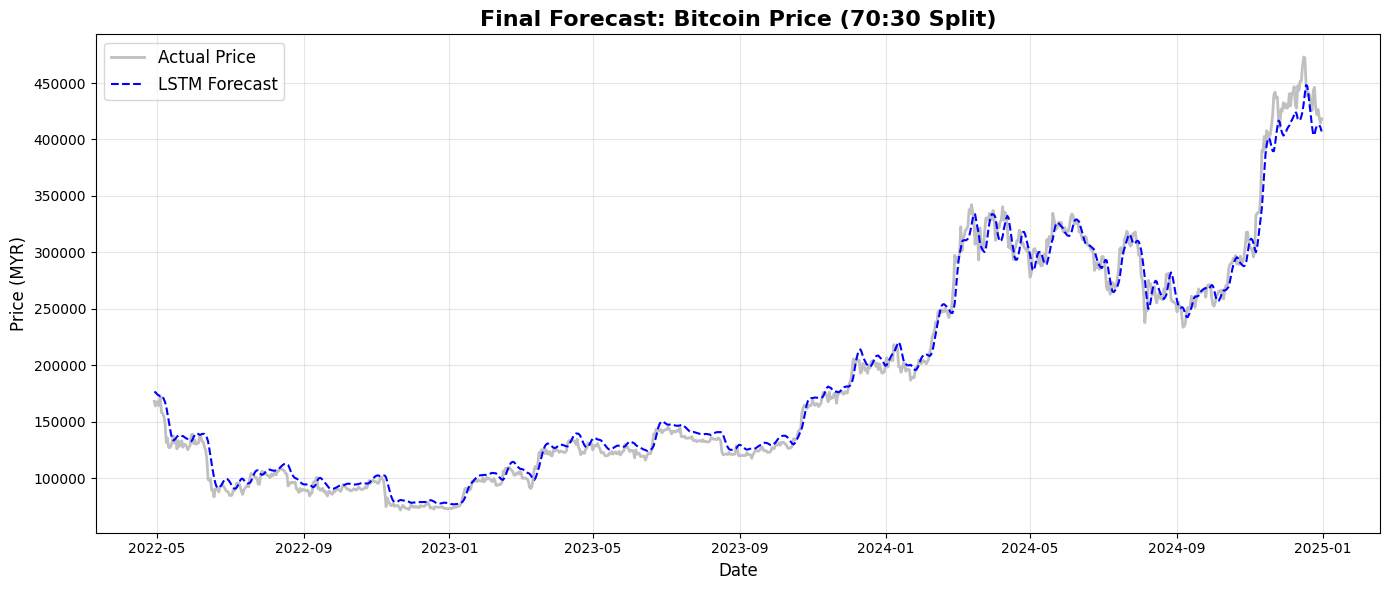


--- Generating Final Plot for Winner: Gold (75:25) ---


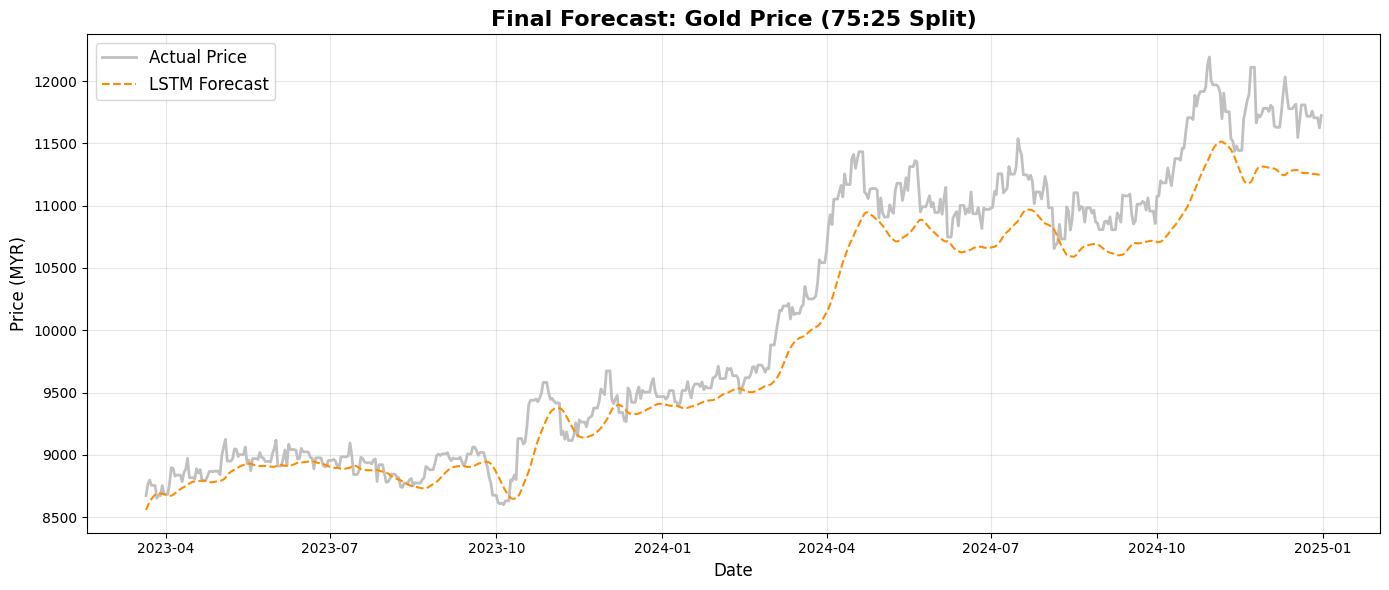

In [56]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# ======================================================
# HELPER FUNCTION: TRAIN & PLOT SPECIFIC WINNER
# ======================================================
def plot_winning_model(df, target_col, split_ratio, split_name, color_pred):
    print(f"\n--- Generating Final Plot for Winner: {target_col} ({split_name}) ---")

    # 1. Setup Data
    feature_cols = ['Bitcoin', 'Gold']
    target_col_idx = feature_cols.index(target_col)
    window_size = 30

    # Scaling
    data_values = df[feature_cols].values
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data_values)

    # Create Sequences
    X, y = [], []
    for i in range(window_size, len(scaled_data)):
        X.append(scaled_data[i-window_size:i, :])
        y.append(scaled_data[i, target_col_idx])
    X, y = np.array(X), np.array(y)

    # Split
    train_size = int(len(X) * split_ratio)
    X_train, y_train = X[:train_size], y[:train_size]
    X_test, y_test = X[train_size:], y[train_size:]

    # 2. Re-Train Model (Quickly)
    tf.random.set_seed(42)
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(window_size, 2)),
        Dropout(0.1),
        LSTM(32),
        Dropout(0.1),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')

    # Silent training
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model.fit(X_train, y_train, validation_data=(X_test, y_test),
              epochs=40, batch_size=32, callbacks=[es], verbose=0)

    # 3. Generate Predictions
    pred_test_scaled = model.predict(X_test, verbose=0)

    # Inverse Transform to get Real Prices (MYR)
    n_features = scaler.n_features_in_
    dummy = np.zeros((len(pred_test_scaled), n_features))
    dummy[:, target_col_idx] = pred_test_scaled.flatten()
    pred_test_real = scaler.inverse_transform(dummy)[:, target_col_idx]

    # Get Actual Prices for the Test Set
    actual_real = df[target_col].iloc[window_size + train_size:].values
    dates_test = df['Date'].iloc[window_size + train_size:]

    # 4. Plotting (The "Money Shot")
    plt.figure(figsize=(14, 6))

    # Plot Actual
    plt.plot(dates_test, actual_real, label='Actual Price', color='silver', linewidth=2)

    # Plot Predicted
    plt.plot(dates_test, pred_test_real, label='LSTM Forecast', color=color_pred, linewidth=1.5, linestyle='--')

    plt.title(f"Final Forecast: {target_col} Price ({split_name} Split)", fontsize=16, fontweight='bold')
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Price (MYR)", fontsize=12)
    plt.legend(loc='upper left', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ======================================================
# EXECUTE FOR THE TWO WINNERS
# ======================================================

# 1. Bitcoin Winner: 70:30 Split
# We use 'Blue' for Bitcoin
plot_winning_model(merged, "Bitcoin", 0.70, "70:30", "blue")

# 2. Gold Winner: 75:25 Split
# We use 'Gold' (Dark Orange/Yellow) for Gold
plot_winning_model(merged, "Gold", 0.8, "75:25", "darkorange")